# Import Libraries

In [2]:
!pip install wordcloud


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install imblearn


   ---------------------------------------- 0/3 [sklearn-compat]
   ---------------------------------------- 0/3 [sklearn-compat]
   ---------------------------------------- 0/3 [sklearn-compat]
   ---------------------------------------- 0/3 [sklearn-compat]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
  


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Load some necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from wordcloud import WordCloud
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score

In [5]:
# Consistent plot style throughout
sns.set_style("whitegrid")
sns.set_palette("Set2")
FRAUD_PALETTE = {0: "#4C9BE8", 1: "#E84C4C"}   # blue = legit, red = fraud
FIG_DPI       = 120

In [6]:
warnings.filterwarnings("ignore")

# Load the datasets

In [7]:
# Load the medical claims data
benf_df = pd.read_csv('Train_Beneficiarydata-1542865627584.csv')
inpatient_df = pd.read_csv('Train_Inpatientdata-1542865627584.csv')
outpatient_df = pd.read_csv('Train_Outpatientdata-1542865627584.csv')
labels_df = pd.read_csv('Train-1542865627584.csv')

# EDA and Data Preprocessing

## Inspecting the datasets

In [8]:
def inspect_data(df, name):

    print(f"\n{'='*60}")
    print(f"DATASET: {name}")
    print(f"{'='*60}")

    print("\nShape:")
    print(df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicate Rows:")
    print(df.duplicated().sum())

    print("\nSample Data:")
    display(df.head())

In [9]:
inspect_data(benf_df, "Beneficiary Data")


DATASET: Beneficiary Data

Shape:
(138556, 25)

Columns:
['BeneID', 'DOB', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator', 'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov', 'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease', 'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression', 'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart', 'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis', 'ChronicCond_stroke', 'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt']

Data Types:
BeneID                             object
DOB                                object
DOD                                object
Gender                              int64
Race                                int64
RenalDiseaseIndicator              object
State                               int64
County                              int64
NoOfMonths_PartACov                 int64
NoOfMonths_Par

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,...,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,...,1,1,1,2,1,1,36000,3204,60,70
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,...,2,2,2,2,2,2,0,0,30,50
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,...,2,2,1,2,2,2,0,0,90,40
3,BENE11004,1922-07-01,NaN,1,1,0,39,270,12,12,...,2,1,1,1,1,2,0,0,1810,760
4,BENE11005,1935-09-01,NaN,1,1,0,24,680,12,12,...,2,1,2,2,2,2,0,0,1790,1200


In [10]:
inspect_data(inpatient_df, "Inpatient Data")


DATASET: Inpatient Data

Shape:
(40474, 30)

Columns:
['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode', 'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6']

Data Types:
BeneID                     object
ClaimID                    object
ClaimStartDt               object
ClaimEndDt                 object
Provider                   object
InscClaimAmtReimbursed      int64
AttendingPhysician         object
OperatingPhysician         object
OtherPhysician             object
AdmissionDt            

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,...,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,...,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,...,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN


In [11]:
inspect_data(outpatient_df, "Outpatient Data")


DATASET: Outpatient Data

Shape:
(517737, 27)

Columns:
['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6', 'DeductibleAmtPaid', 'ClmAdmitDiagnosisCode']

Data Types:
BeneID                     object
ClaimID                    object
ClaimStartDt               object
ClaimEndDt                 object
Provider                   object
InscClaimAmtReimbursed      int64
AttendingPhysician         object
OperatingPhysician         object
OtherPhysician             object
ClmDiagnosisCode_1         object
ClmDiagnosisCode_2         object
ClmDi

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,...,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DeductibleAmtPaid,ClmAdmitDiagnosisCode
0,BENE11002,CLM624349,2009-10-11,2009-10-11,PRV56011,30,PHY326117,NaN,NaN,78943,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,56409
1,BENE11003,CLM189947,2009-02-12,2009-02-12,PRV57610,80,PHY362868,NaN,NaN,6115,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,79380
2,BENE11003,CLM438021,2009-06-27,2009-06-27,PRV57595,10,PHY328821,NaN,NaN,2723,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,BENE11004,CLM121801,2009-01-06,2009-01-06,PRV56011,40,PHY334319,NaN,NaN,71988,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
4,BENE11004,CLM150998,2009-01-22,2009-01-22,PRV56011,200,PHY403831,NaN,NaN,82382,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,71947


In [12]:
inspect_data(labels_df, "Fraud Data")


DATASET: Fraud Data

Shape:
(5410, 2)

Columns:
['Provider', 'PotentialFraud']

Data Types:
Provider          object
PotentialFraud    object
dtype: object

Missing Values:
Provider          0
PotentialFraud    0
dtype: int64

Duplicate Rows:
0

Sample Data:


,Provider,PotentialFraud
0,PRV51001,No
1,PRV51003,Yes
2,PRV51004,No
3,PRV51005,Yes
4,PRV51007,No


| Dataset     | Key Column      |
| ----------- | --------------- |
| beneficiary | BeneID          |
| inpatient   | BeneID, ClaimID |
| outpatient  | BeneID, ClaimID |
| fraud       | Provider        |

We will merge datasets to create one master dataset.

## Label - Class Distribution

In [13]:
fraud_counts = labels_df["PotentialFraud"].value_counts()
fraud_pct    = labels_df["PotentialFraud"].value_counts(normalize=True) * 100

print(fraud_counts)
print()
print(fraud_pct.round(2))

PotentialFraud
No     4904
Yes     506
Name: count, dtype: int64

PotentialFraud
No     90.65
Yes     9.35
Name: proportion, dtype: float64


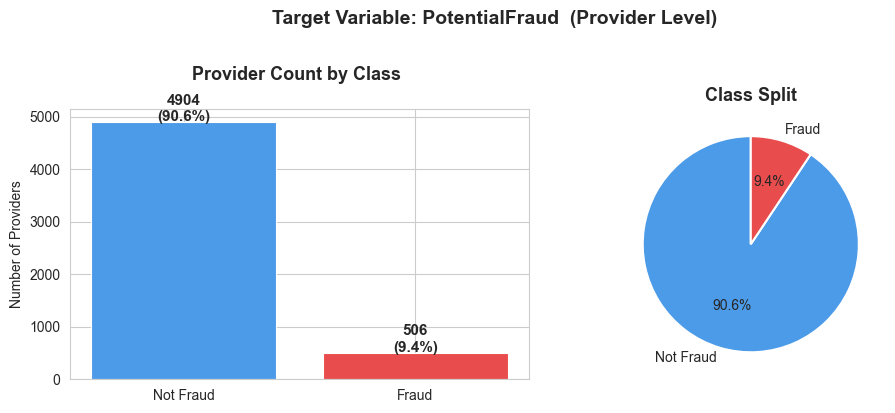

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["Not Fraud", "Fraud"],
            [fraud_counts["No"], fraud_counts["Yes"]],
            color=["#4C9BE8", "#E84C4C"], edgecolor="white", linewidth=0.8)
axes[0].set_title("Provider Count by Class \n", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Providers")

for i, (label, val) in enumerate(zip(["No", "Yes"], [fraud_counts["No"], fraud_counts["Yes"]])):
    axes[0].text(i, val + 20, f"{val}\n({fraud_pct[label]:.1f}%)",
                 ha="center", fontweight="bold", fontsize=11)

axes[1].pie([fraud_counts["No"], fraud_counts["Yes"]],
            labels=["Not Fraud", "Fraud"],
            colors=["#4C9BE8", "#E84C4C"],
            autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[1].set_title("Class Split", fontsize=13, fontweight="bold")

plt.suptitle("Target Variable: PotentialFraud  (Provider Level)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

- The plot reveals a significant class imbalance:

  - 4,904 providers (90.6%) are labelled as Not Fraud
  - 506 providers (9.4%) are labelled as Fraud

This means for every 1 fraudulent provider, there are approximately 9.7 legitimate providers — a roughly 10:1 imbalance ratio.

---

In fraud detection, missing a fraudulent provider (False Negative) is far more costly than incorrectly flagging a legitimate one (False Positive). This means we will deliberately tune our model to maximise Recall, even at the cost of some Precision — a trade-off we will explore through threshold tuning.

## Beneficiary dataset

In [15]:
null_bene = benf_df.isnull().sum()
null_bene = null_bene[null_bene > 0]
print("Columns with nulls:")
print(null_bene)
print()
print("Sample rows:")
benf_df.head(3)

Columns with nulls:
DOD    137135
dtype: int64

Sample rows:


,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,...,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,...,1,1,1,2,1,1,36000,3204,60,70
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,...,2,2,2,2,2,2,0,0,30,50
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,...,2,2,1,2,2,2,0,0,90,40


In [16]:
# Check the actual date range in the claims data
print("Inpatient ClaimStartdate range:")
print("  Start:", inpatient_df["ClaimStartDt"].min(), "→", inpatient_df["ClaimStartDt"].max())
print("  End  :", inpatient_df["ClaimEndDt"].min(),   "→", inpatient_df["ClaimEndDt"].max())

print("\nOutpatient ClaimStartDt range:")
print("  Start:", outpatient_df["ClaimStartDt"].min(), "→", outpatient_df["ClaimStartDt"].max())

print("\nBeneficiary DOB range:")
print(" ", benf_df["DOB"].min(), "→", benf_df["DOB"].max())

print("\nBeneficiary DOD (non-null):")
print(" ", benf_df["DOD"].dropna().min(), "→", benf_df["DOD"].dropna().max())

Inpatient ClaimStartdate range:
  Start: 2008-11-27 → 2009-12-31
  End  : 2009-01-01 → 2009-12-31

Outpatient ClaimStartDt range:


  Start: 2008-12-12 → 2009-12-31

Beneficiary DOB range:
  1909-01-01 → 1983-12-01

Beneficiary DOD (non-null):
  2009-02-01 → 2009-12-01


In [17]:
REF_DATE = max(inpatient_df["ClaimEndDt"].max(), outpatient_df["ClaimEndDt"].max()) #Last actual activity in the dataset
REF_DATE = pd.to_datetime(REF_DATE) # Convert REF_DATE to datetime

benf_df["DOB"] = pd.to_datetime(benf_df["DOB"])
benf_df["DOD"] = pd.to_datetime(benf_df["DOD"], errors="coerce")

benf_df["Age"]    = ((REF_DATE - benf_df["DOB"]).dt.days / 365.25).astype(int)
benf_df["IsDead"] = benf_df["DOD"].notna().astype(int)

In [18]:
benf_df[['DOB','DOD','Age','IsDead']].head(20)

,DOB,DOD,Age,IsDead
0,1943-01-01,NaT,66,0
1,1936-09-01,NaT,73,0
2,1936-08-01,NaT,73,0
3,1922-07-01,NaT,87,0
4,1935-09-01,NaT,74,0
5,1976-09-01,NaT,33,0
6,1940-09-01,2009-12-01,69,1
7,1934-02-01,NaT,75,0
8,1929-06-01,NaT,80,0
9,1936-07-01,NaT,73,0


In [19]:
# Chronic conditions: recode 2 → 0 (the dataset uses 1=Yes, 2=No)
CHRONIC_COLS = [c for c in benf_df.columns if c.startswith("ChronicCond_")]
for col in CHRONIC_COLS:
    benf_df[col] = (benf_df[col] == 1).astype(int) # 1 -> 1    2-> 0

# Total number of chronic conditions per beneficiary
benf_df["ChronicCondCount"] = benf_df[CHRONIC_COLS].sum(axis=1)

In [20]:
benf_df.head(10)

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,...,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,IsDead,ChronicCondCount
0,BENE11001,1943-01-01,NaT,1,1,0,39,230,12,12,...,0,1,1,36000,3204,60,70,66,0,7
1,BENE11002,1936-09-01,NaT,2,1,0,39,280,12,12,...,0,0,0,0,0,30,50,73,0,0
2,BENE11003,1936-08-01,NaT,1,1,0,52,590,12,12,...,0,0,0,0,0,90,40,73,0,2
3,BENE11004,1922-07-01,NaT,1,1,0,39,270,12,12,...,1,1,0,0,0,1810,760,87,0,6
4,BENE11005,1935-09-01,NaT,1,1,0,24,680,12,12,...,0,0,0,0,0,1790,1200,74,0,2
5,BENE11006,1976-09-01,NaT,2,1,0,23,810,12,12,...,0,0,0,0,0,500,0,33,0,0
6,BENE11007,1940-09-01,2009-12-01,1,2,0,45,610,12,12,...,1,1,0,0,0,1490,160,69,1,5
7,BENE11008,1934-02-01,NaT,2,1,0,15,140,12,12,...,0,0,0,0,0,30,0,75,0,1
8,BENE11009,1929-06-01,NaT,1,1,Y,44,230,12,12,...,0,0,0,0,0,100,0,80,0,2
9,BENE11010,1936-07-01,NaT,2,1,0,41,30,12,12,...,1,0,0,0,0,1170,660,73,0,6


In [21]:
# RenalDiseaseIndicator: 'Y' → 1, else → 0
benf_df["RenalDiseaseIndicator"] = benf_df["RenalDiseaseIndicator"].map({'Y': 1, '0': 0})

print("Beneficiary cleaning done")
print(benf_df[["BeneID", "DOB", "Age", "IsDead", "ChronicCondCount"]].head(10))

Beneficiary cleaning done
      BeneID        DOB  Age  IsDead  ChronicCondCount
0  BENE11001 1943-01-01   66       0                 7
1  BENE11002 1936-09-01   73       0                 0
2  BENE11003 1936-08-01   73       0                 2
3  BENE11004 1922-07-01   87       0                 6
4  BENE11005 1935-09-01   74       0                 2
5  BENE11006 1976-09-01   33       0                 0
6  BENE11007 1940-09-01   69       1                 5
7  BENE11008 1934-02-01   75       0                 1
8  BENE11009 1929-06-01   80       0                 2
9  BENE11010 1936-07-01   73       0                 6


In [22]:
# Gender: 1=Male → 1, 2=Female → 0
benf_df["Gender"] = (benf_df["Gender"] == 1).astype(int)

In [23]:
benf_df.head(20)

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,...,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,IsDead,ChronicCondCount
0,BENE11001,1943-01-01,NaT,1,1,0,39,230,12,12,...,0,1,1,36000,3204,60,70,66,0,7
1,BENE11002,1936-09-01,NaT,0,1,0,39,280,12,12,...,0,0,0,0,0,30,50,73,0,0
2,BENE11003,1936-08-01,NaT,1,1,0,52,590,12,12,...,0,0,0,0,0,90,40,73,0,2
3,BENE11004,1922-07-01,NaT,1,1,0,39,270,12,12,...,1,1,0,0,0,1810,760,87,0,6
4,BENE11005,1935-09-01,NaT,1,1,0,24,680,12,12,...,0,0,0,0,0,1790,1200,74,0,2
5,BENE11006,1976-09-01,NaT,0,1,0,23,810,12,12,...,0,0,0,0,0,500,0,33,0,0
6,BENE11007,1940-09-01,2009-12-01,1,2,0,45,610,12,12,...,1,1,0,0,0,1490,160,69,1,5
7,BENE11008,1934-02-01,NaT,0,1,0,15,140,12,12,...,0,0,0,0,0,30,0,75,0,1
8,BENE11009,1929-06-01,NaT,1,1,1,44,230,12,12,...,0,0,0,0,0,100,0,80,0,2
9,BENE11010,1936-07-01,NaT,0,1,0,41,30,12,12,...,1,0,0,0,0,1170,660,73,0,6


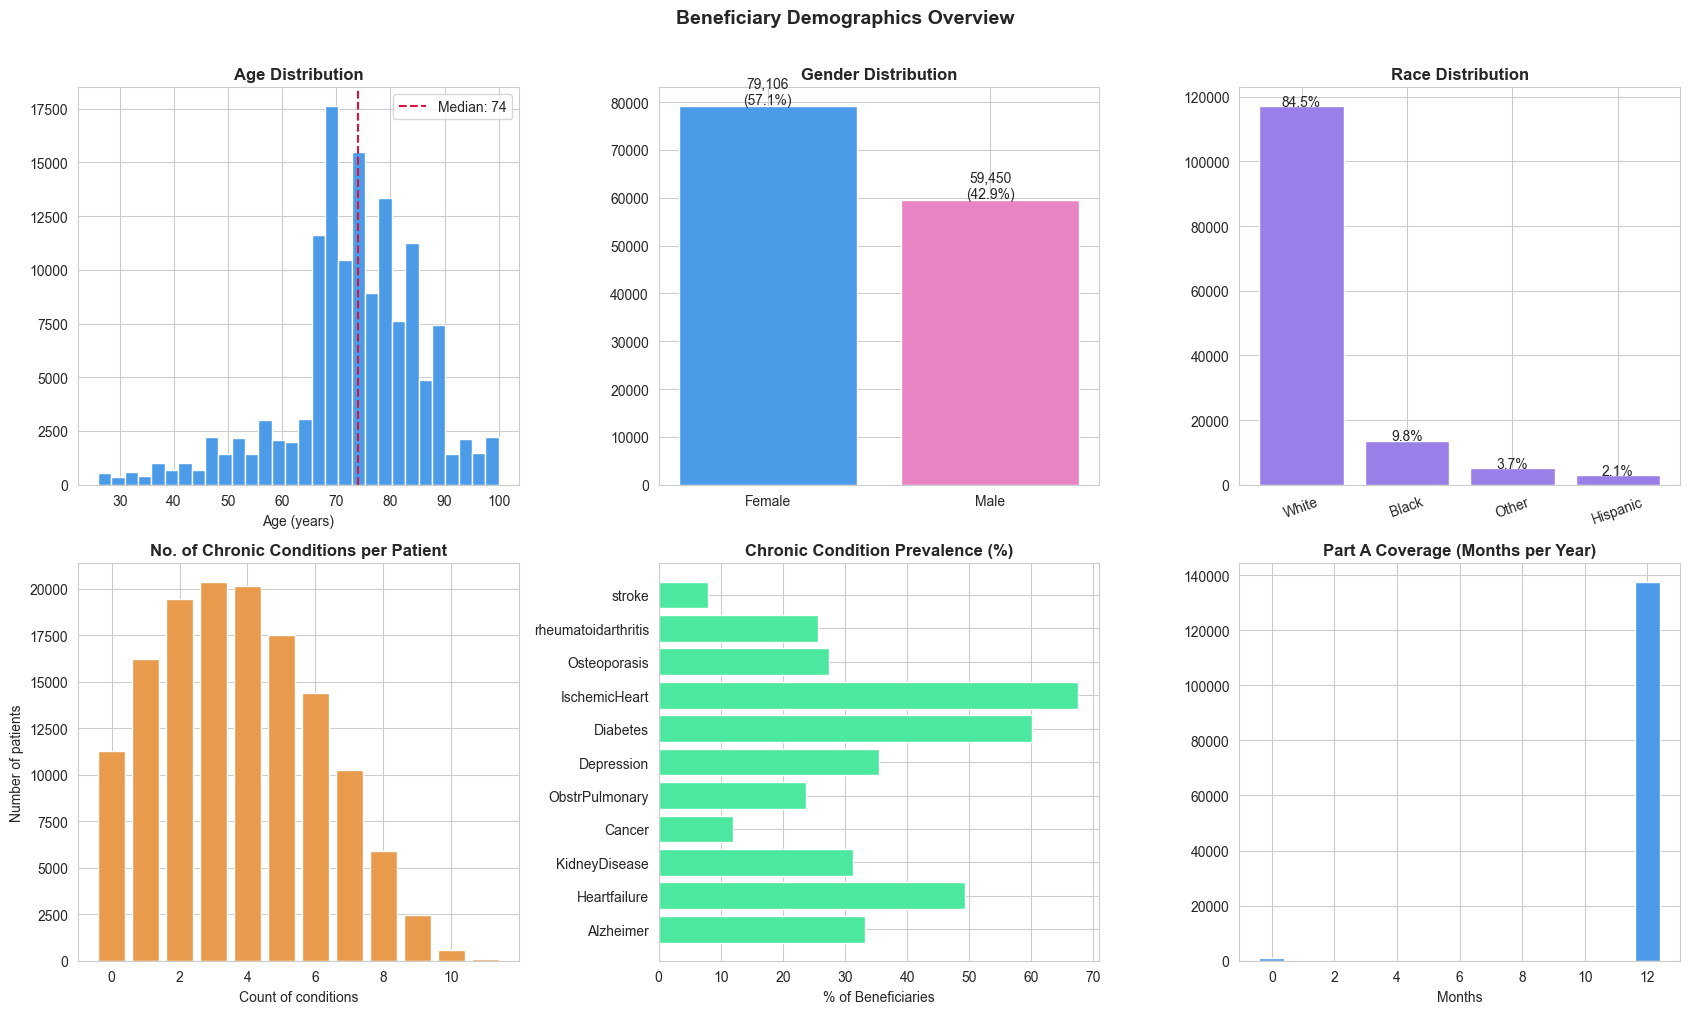

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# Age distribution
axes[0, 0].hist(benf_df["Age"], bins=30, color="#4C9BE8", edgecolor="white")
axes[0, 0].axvline(benf_df["Age"].median(), color="crimson",
                   linestyle="--", label=f"Median: {benf_df['Age'].median():.0f}")
axes[0, 0].set_title("Age Distribution", fontweight="bold")
axes[0, 0].set_xlabel("Age (years)")
axes[0, 0].legend()

# Gender
gender_map = {1: "Male", 0: "Female"}
gender_ct  = benf_df["Gender"].map(gender_map).value_counts()
axes[0, 1].bar(gender_ct.index, gender_ct.values,
               color=["#4C9BE8", "#E884C4"], edgecolor="white")
axes[0, 1].set_title("Gender Distribution", fontweight="bold")
for i, v in enumerate(gender_ct.values):
    axes[0, 1].text(i, v + 400, f"{v:,}\n({v/len(benf_df)*100:.1f}%)",
                    ha="center", fontsize=10)

# Race
# based on standard Medicare race coding
race_map = {1:"White", 2:"Black", 3:"Other", 5:"Hispanic"}
race_ct  = benf_df["Race"].map(race_map).value_counts()
axes[0, 2].bar(race_ct.index, race_ct.values, color="#9B7FE8", edgecolor="white")
axes[0, 2].set_title("Race Distribution", fontweight="bold")
for i, v in enumerate(race_ct.values):
    axes[0, 2].text(i, v + 200, f"{v/len(benf_df)*100:.1f}%", ha="center", fontsize=10)
axes[0, 2].tick_params(axis="x", rotation=20)

# Chronic condition counts
cc_ct = benf_df["ChronicCondCount"].value_counts().sort_index()
axes[1, 0].bar(cc_ct.index, cc_ct.values, color="#E89B4C", edgecolor="white")
axes[1, 0].set_title("No. of Chronic Conditions per Patient", fontweight="bold")
axes[1, 0].set_xlabel("Count of conditions")
axes[1, 0].set_ylabel("Number of patients")

# Individual chronic condition prevalence
chron_pct = benf_df[CHRONIC_COLS].mean() * 100
chron_labels = [c.replace("ChronicCond_", "") for c in CHRONIC_COLS]
axes[1, 1].barh(chron_labels, chron_pct.values, color="#4CE8A0", edgecolor="white")
axes[1, 1].set_title("Chronic Condition Prevalence (%)", fontweight="bold")
axes[1, 1].set_xlabel("% of Beneficiaries")

# Coverage months
part_a = benf_df["NoOfMonths_PartACov"].value_counts().sort_index()
axes[1, 2].bar(part_a.index, part_a.values, color="#4C9BE8", edgecolor="white")
axes[1, 2].set_title("Part A Coverage (Months per Year)", fontweight="bold")
axes[1, 2].set_xlabel("Months")

plt.suptitle("Beneficiary Demographics Overview", fontsize=14,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

1. Age Distribution

The beneficiary population is concentrated between 65 and 85 years, with a median age of 74 years. This is expected — this is a Medicare dataset, which primarily covers individuals aged 65 and older. The small cluster of younger patients (below 60) likely represents individuals qualifying through disability. The right tail extending to 100+ indicates a meaningful elderly population, which is important because older patients typically have more complex and expensive medical needs.

<br>

2. Gender Distribution

The dataset has a slight female majority — 79,106 females (57.1%) vs 59,450 males (42.9%). This aligns with general Medicare demographics, as women on average have longer lifespans and therefore make up a larger share of the elderly insured population.

<br>

3. Race Distribution

The beneficiary pool is predominantly White (84.5%), followed by Black (9.8%), Other (3.7%), and Hispanic (2.1%). This demographic skew is worth noting as it reflects the underlying Medicare population composition, not a sampling bias.

<br>

4. Chronic Conditions per Patient

Most patients carry 3 to 5 chronic conditions simultaneously, with the distribution peaking around 4–5. Very few patients have zero chronic conditions, which makes sense given the elderly population. This high chronic condition burden directly drives high claim volumes and reimbursement amounts — making it a critical feature for distinguishing normal billing from fraud.

<br>

5. Chronic Condition Prevalence

Ischemic Heart Disease (~ 67%) and Diabetes (~ 62%) are by far the most prevalent conditions, affecting the majority of beneficiaries. Heart Failure (~ 48%) and Depression (~ 35%) follow. Stroke and Cancer are the least common. Fraudulent providers may disproportionately bill for high-reimbursement conditions like Ischemic Heart Disease, making these flags useful for fraud detection.

<br>

6. Part A Coverage

The vast majority of beneficiaries are covered for the full 12 months of the year, with almost no patients covered for fewer than 12 months. This means coverage duration adds very little discriminative power as a feature and can effectively be dropped or ignored during feature selection.

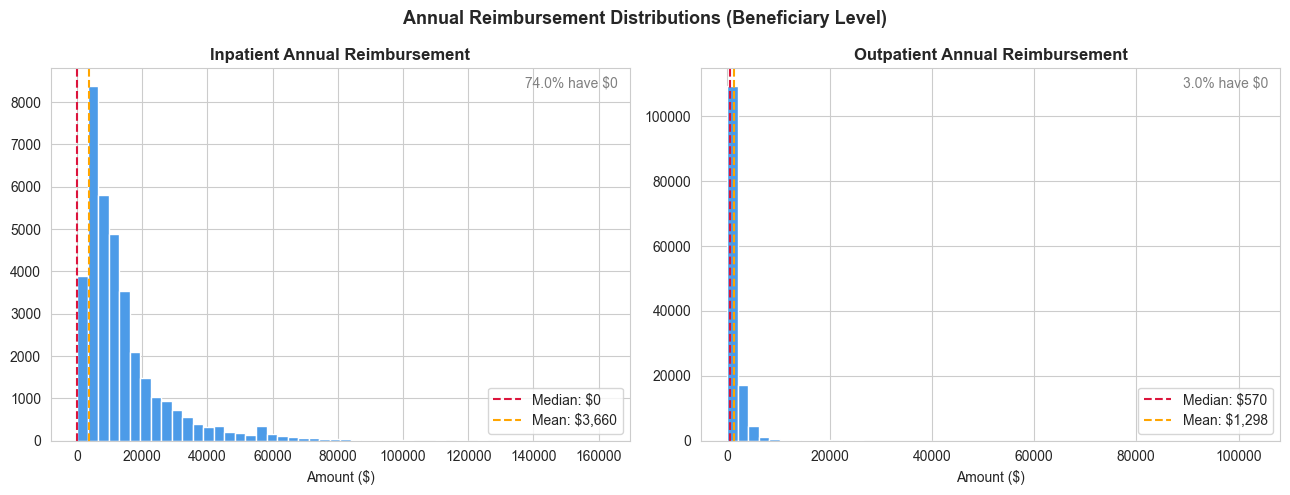

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in [
    (axes[0], "IPAnnualReimbursementAmt", "Inpatient Annual Reimbursement"),
    (axes[1], "OPAnnualReimbursementAmt", "Outpatient Annual Reimbursement")
]:
    data = benf_df[col]
    ax.hist(data[data > 0], bins=50, color="#4C9BE8", edgecolor="white")
    ax.axvline(data.median(), color="crimson", linestyle="--",
               label=f"Median: ${data.median():,.0f}")
    ax.axvline(data.mean(), color="orange", linestyle="--",
               label=f"Mean: ${data.mean():,.0f}")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Amount ($)")
    ax.legend()
    # Print % of zero-reimbursement beneficiaries
    pct_zero = (data == 0).mean() * 100
    ax.text(0.98, 0.95, f"{pct_zero:.1f}% have $0",
            transform=ax.transAxes, ha="right", fontsize=10, color="gray")

plt.suptitle("Annual Reimbursement Distributions (Beneficiary Level)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### Inpatient Annual Reimbursement

The inpatient distribution is extremely right-skewed with a striking split:

- 74% of beneficiaries have \$0 inpatient reimbursement — meaning nearly three-quarters of patients had no hospital admissions at all during the year

- Among those who did have inpatient claims, reimbursements range widely from a few thousand dollars up to \$160,000+

- The median is `$0` (pulled down by the majority with no inpatient claims), while the mean is $3,660 — a large gap that confirms the heavy skew

- Active claimants cluster between `$5,000`–`$20,000`, with a long tail extending all the way to `$160,000+` representing patients with multiple or very complex hospital admissions

This tells us inpatient care is expensive but rare — most patients never get admitted. A provider submitting unusually high inpatient volumes or reimbursements is therefore a strong fraud signal.

---

### Outpatient Annual Reimbursement
The outpatient picture is very different:

- Only 3% of beneficiaries have \$0 outpatient reimbursement — meaning almost everyone uses outpatient services

- The distribution is again heavily right-skewed, with most patients clustering near \$0 - \$2,000

- The median is \$570 and the mean is `$1,298`, a smaller gap than inpatient, reflecting more consistent low-cost usage

- A long right tail extends to $100,000+, representing patients with chronic conditions requiring frequent outpatient visits

Fraudulent providers may artificially convert outpatient visits into inpatient admissions to claim the higher reimbursement rates — a pattern known as upcoding

## Inpatient dataset

In [26]:
print("=" * 55)
print("INPATIENT DATASET  —  Null Analysis")
print("=" * 55)

null_inp = inpatient_df.isnull().sum()
null_pct  = (null_inp / len(inpatient_df) * 100).round(1)
null_df   = pd.DataFrame({"Missing": null_inp, "Missing%": null_pct})
null_df   = null_df[null_df["Missing"] > 0].sort_values("Missing%", ascending=False)
print(null_df)
print()
print(f"Total rows: {len(inpatient_df):,}")

INPATIENT DATASET  —  Null Analysis
                     Missing  Missing%
ClmProcedureCode_6     40474     100.0
ClmProcedureCode_5     40465     100.0
ClmProcedureCode_4     40358      99.7
ClmProcedureCode_3     39509      97.6
ClmDiagnosisCode_10    36547      90.3
OtherPhysician         35784      88.4
ClmProcedureCode_2     35020      86.5
ClmProcedureCode_1     17326      42.8
OperatingPhysician     16644      41.1
ClmDiagnosisCode_9     13497      33.3
ClmDiagnosisCode_8      9942      24.6
ClmDiagnosisCode_7      7258      17.9
ClmDiagnosisCode_6      4838      12.0
ClmDiagnosisCode_5      2894       7.2
ClmDiagnosisCode_4      1534       3.8
DeductibleAmtPaid        899       2.2
ClmDiagnosisCode_3       676       1.7
ClmDiagnosisCode_2       226       0.6
AttendingPhysician       112       0.3

Total rows: 40,474


In [27]:
inpatient_df.columns

Index(['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician',
       'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode',
       'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode',
       'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3',
       'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6',
       'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9',
       'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2',
       'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5',
       'ClmProcedureCode_6'],
      dtype='object')

In [28]:
DATE_COLS_INP = ["ClaimStartDt", "ClaimEndDt", "AdmissionDt", "DischargeDt"]
for col in DATE_COLS_INP:
    inpatient_df[col] = pd.to_datetime(inpatient_df[col])

inpatient_df["ClaimDuration"]  = (inpatient_df["ClaimEndDt"]   - inpatient_df["ClaimStartDt"]).dt.days
inpatient_df["DaysInHospital"] = (inpatient_df["DischargeDt"]  - inpatient_df["AdmissionDt"]).dt.days

In [29]:
inpatient_df.columns

Index(['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician',
       'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode',
       'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode',
       'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3',
       'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6',
       'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9',
       'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2',
       'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5',
       'ClmProcedureCode_6', 'ClaimDuration', 'DaysInHospital'],
      dtype='object')

In [30]:
# The .clip(lower=0) method replaces any value less than 0 with 0, effectively handling cases where claim duration and DaysInHospital might have been calculated as a negative number due to data inconsistencies.
inpatient_df["ClaimDuration"]  = inpatient_df["ClaimDuration"].clip(lower=0)
inpatient_df["DaysInHospital"] = inpatient_df["DaysInHospital"].clip(lower=0)

# DeductibleAmtPaid has 899 missing values (~2.2%). A missing deductible most likely means
# the patient paid nothing out of pocket for that claim, so filling with 0 is the correct business interpretation — not an assumption.
inpatient_df["DeductibleAmtPaid"] = inpatient_df["DeductibleAmtPaid"].fillna(0)

In [31]:
# Each claim can have up to 10 diagnosis codes, but most claims have only 1–3. Columns like ClmDiagnosisCode_7
# through _10 are mostly empty — not because data is missing, but because the patient simply had fewer diagnoses.
# Filling with "NONE" makes the absence explicit and prevents errors downstream during feature engineering.
DIAG_COLS = [f"ClmDiagnosisCode_{i}" for i in range(1, 11)]
for col in DIAG_COLS:
    inpatient_df[col] = inpatient_df[col].fillna("NONE")

In [32]:
PROC_COLS = [f"ClmProcedureCode_{i}" for i in range(1, 7)]
for col in PROC_COLS:
    inpatient_df[col] = inpatient_df[col].fillna(0).astype(int).astype(str)
    inpatient_df[col] = inpatient_df[col].replace("0", "NONE")

In [33]:
# This creates a binary fraud indicator feature.
# It flags claims where the same doctor is listed as both the attending physician
# (who oversees care) and the operating physician (who performs the procedure).
# In legitimate practice these are usually different people. When the same physician fills both roles,
# it can indicate phantom billing — a claim submitted for a procedure that never happened.
inpatient_df["SameAttendOper"] = (
    inpatient_df["AttendingPhysician"].notna() &
    inpatient_df["OperatingPhysician"].notna() &
    (inpatient_df["AttendingPhysician"] == inpatient_df["OperatingPhysician"])
).astype(int)

In [34]:
print("Inpatient cleaning done")
print(inpatient_df[["ClaimID", "ClaimDuration", "DaysInHospital","DeductibleAmtPaid", "SameAttendOper"]].describe())

Inpatient cleaning done
       ClaimDuration  DaysInHospital  DeductibleAmtPaid  SameAttendOper
count   40474.000000    40474.000000       40474.000000    40474.000000
mean        5.660251        5.665168        1044.277808        0.163265
std         5.628873        5.638538         157.394952        0.369612
min         0.000000        0.000000           0.000000        0.000000
25%         2.000000        2.000000        1068.000000        0.000000
50%         4.000000        4.000000        1068.000000        0.000000
75%         7.000000        7.000000        1068.000000        0.000000
max        36.000000       35.000000        1068.000000        1.000000


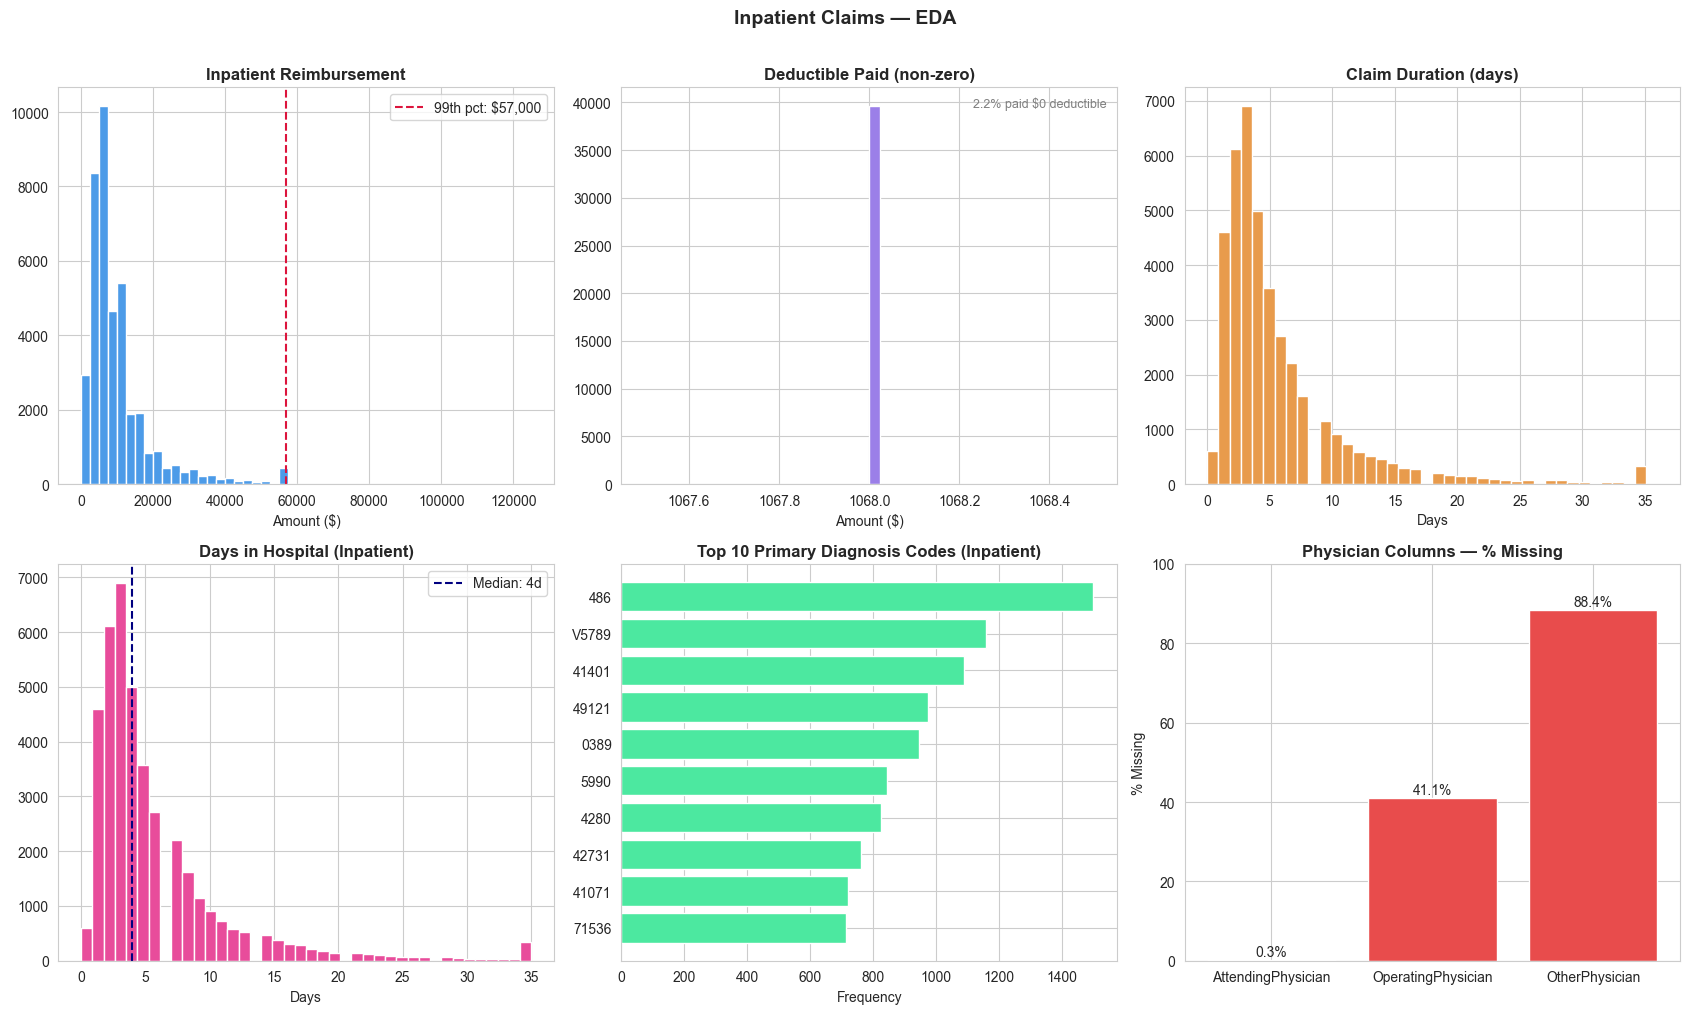

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# Reimbursement amount distribution
axes[0, 0].hist(inpatient_df["InscClaimAmtReimbursed"], bins=50,
                color="#4C9BE8", edgecolor="white")
axes[0, 0].set_title("Inpatient Reimbursement", fontweight="bold")
axes[0, 0].set_xlabel("Amount ($)")
q99 = inpatient_df["InscClaimAmtReimbursed"].quantile(0.99)
axes[0, 0].axvline(q99, color="crimson", linestyle="--",
                   label=f"99th pct: ${q99:,.0f}")
axes[0, 0].legend()

# Deductible distribution (non-zero only)
ded_nz = inpatient_df.loc[inpatient_df["DeductibleAmtPaid"] > 0, "DeductibleAmtPaid"]
axes[0, 1].hist(ded_nz, bins=40, color="#9B7FE8", edgecolor="white")
axes[0, 1].set_title("Deductible Paid (non-zero)", fontweight="bold")
axes[0, 1].set_xlabel("Amount ($)")
pct_zero_ded = (inpatient_df["DeductibleAmtPaid"] == 0).mean() * 100
axes[0, 1].text(0.98, 0.95, f"{pct_zero_ded:.1f}% paid $0 deductible",
                transform=axes[0, 1].transAxes, ha="right", fontsize=9, color="gray")

# Claim duration
axes[0, 2].hist(inpatient_df["ClaimDuration"], bins=40, color="#E89B4C", edgecolor="white")
axes[0, 2].set_title("Claim Duration (days)", fontweight="bold")
axes[0, 2].set_xlabel("Days")

# Days in hospital
axes[1, 0].hist(inpatient_df["DaysInHospital"], bins=40, color="#E84C9B", edgecolor="white")
axes[1, 0].set_title("Days in Hospital (Inpatient)", fontweight="bold")
axes[1, 0].set_xlabel("Days")
axes[1, 0].axvline(inpatient_df["DaysInHospital"].median(), color="navy",
                   linestyle="--", label=f"Median: {inpatient_df['DaysInHospital'].median():.0f}d")
axes[1, 0].legend()

# Top 10 primary diagnosis codes
top_diag = inpatient_df["ClmDiagnosisCode_1"].value_counts().head(10)
axes[1, 1].barh(top_diag.index[::-1], top_diag.values[::-1],
                color="#4CE8A0", edgecolor="white")
axes[1, 1].set_title("Top 10 Primary Diagnosis Codes (Inpatient)", fontweight="bold")
axes[1, 1].set_xlabel("Frequency")

# Missing physicians overview
phys_miss = pd.Series({
    "AttendingPhysician": inpatient_df["AttendingPhysician"].isna().mean() * 100,
    "OperatingPhysician": inpatient_df["OperatingPhysician"].isna().mean() * 100,
    "OtherPhysician":     inpatient_df["OtherPhysician"].isna().mean() * 100
})
axes[1, 2].bar(phys_miss.index, phys_miss.values, color="#E84C4C", edgecolor="white")
axes[1, 2].set_title("Physician Columns — % Missing", fontweight="bold")
axes[1, 2].set_ylabel("% Missing")
axes[1, 2].set_ylim(0, 100)

for i, v in enumerate(phys_miss.values):
    axes[1, 2].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10)

plt.suptitle("Inpatient Claims — EDA", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 1. Inpatient Reimbursement
- The reimbursement amounts are heavily right-skewed. The majority of claims are reimbursed between `$0`–`$20,000`, with the distribution dropping sharply after that.
- The 99th percentile sits at `$57,000`, meaning only 1% of claims exceed this amount — but those extreme values can be very large (up to `$120,000+`). This skew is why we apply Winsorization at the 99th percentile before modelling, to prevent a handful of extreme claims from disproportionately influencing the model.

### 2. Deductible Paid (non-zero)
- This plot shows a striking anomaly — nearly all non-zero deductible payments are concentrated at exactly `$1,068`. This is not a data error; it reflects the fixed Medicare Part A deductible for inpatient hospital stays, which was `$1,068` in the dataset's reference year (2009).

- The note that 2.2% paid $0 deductible means most patients who were admitted did pay the standard deductible. This column has very low variance and will likely contribute little predictive power on its own.

### 3. Claim Duration (days)
- Most claims have a duration of 1–7 days, with the distribution peaking around 1–2 days and tapering off sharply.
- A small number of claims extend beyond 20–35 days, which could represent either legitimate long-term care or suspicious prolonged billing. The right tail is worth flagging — unusually long claim durations at the provider level are a known fraud indicator.

### 4. Days in Hospital (Inpatient)
- The median hospital stay is 4 days, which aligns with typical inpatient admission patterns. The distribution is right-skewed with most stays falling between 1–8 days.
- Stays extending beyond 15–20 days are rare and could represent either genuinely complex cases or inflated billing. At the provider level, average days in hospital will be one of our most important features — fraudulent providers tend to show systematically longer stays across their patient base.

### 5. Top 10 Primary Diagnosis Codes (Inpatient)
- Code 486 (Pneumonia) is the most frequently billed inpatient diagnosis by a significant margin, followed by V5789 (other aftercare), 41401 (Coronary artery disease), and 49121 (Obstructive chronic bronchitis).
- These codes represent high-cost, high-reimbursement conditions that are difficult to disprove without detailed clinical records — which is precisely why they are commonly associated with fraudulent billing. We will extract the top 100 diagnosis codes as binary provider-level features in our feature engineering step.

### 6. Physician Columns — % Missing
- The three physician columns show very different missingness patterns:

  - AttendingPhysician — 0.3% missing: Almost always recorded. Every inpatient admission should have a supervising physician, so this is expected.
  - OperatingPhysician — 41.1% missing: Not every admission involves a surgical procedure, so missing here is legitimate — it simply means no operation was performed.
  - OtherPhysician — 88.4% missing: Rarely recorded and mostly empty. This column will be dropped from the feature set as it adds almost no information.

## Outpatient dataset

In [36]:
outpatient_df.columns

Index(['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician',
       'OtherPhysician', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2',
       'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5',
       'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8',
       'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10', 'ClmProcedureCode_1',
       'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4',
       'ClmProcedureCode_5', 'ClmProcedureCode_6', 'DeductibleAmtPaid',
       'ClmAdmitDiagnosisCode'],
      dtype='object')

In [37]:
DATE_COLS_OUT = ["ClaimStartDt", "ClaimEndDt"]
for col in DATE_COLS_OUT:
    outpatient_df[col] = pd.to_datetime(outpatient_df[col])

outpatient_df["ClaimDuration"] = (outpatient_df["ClaimEndDt"] - outpatient_df["ClaimStartDt"]).dt.days
outpatient_df["ClaimDuration"] = outpatient_df["ClaimDuration"].clip(lower=0)

In [38]:
for col in DIAG_COLS:
    outpatient_df[col] = outpatient_df[col].fillna("NONE")

for col in PROC_COLS:
    outpatient_df[col] = outpatient_df[col].fillna(0).astype(int).astype(str)
    outpatient_df[col] = outpatient_df[col].replace("0", "NONE")

In [39]:
outpatient_df["ClmAdmitDiagnosisCode"] = outpatient_df["ClmAdmitDiagnosisCode"].fillna("NONE")

In [40]:
outpatient_df["SameAttendOper"] = (
    outpatient_df["AttendingPhysician"].notna() &
    outpatient_df["OperatingPhysician"].notna() &
    (outpatient_df["AttendingPhysician"] == outpatient_df["OperatingPhysician"])
).astype(int)

# Outpatient has no Admission/Discharge → set hospital days to 0
outpatient_df["DaysInHospital"] = 0

In [41]:
print("Outpatient cleaning done")
print(outpatient_df[["ClaimID", "ClaimDuration", "SameAttendOper"]].describe())

Outpatient cleaning done
       ClaimDuration  SameAttendOper
count  517737.000000   517737.000000
mean        1.420532        0.105374
std         4.707387        0.307035
min         0.000000        0.000000
25%         0.000000        0.000000
50%         0.000000        0.000000
75%         0.000000        0.000000
max        23.000000        1.000000


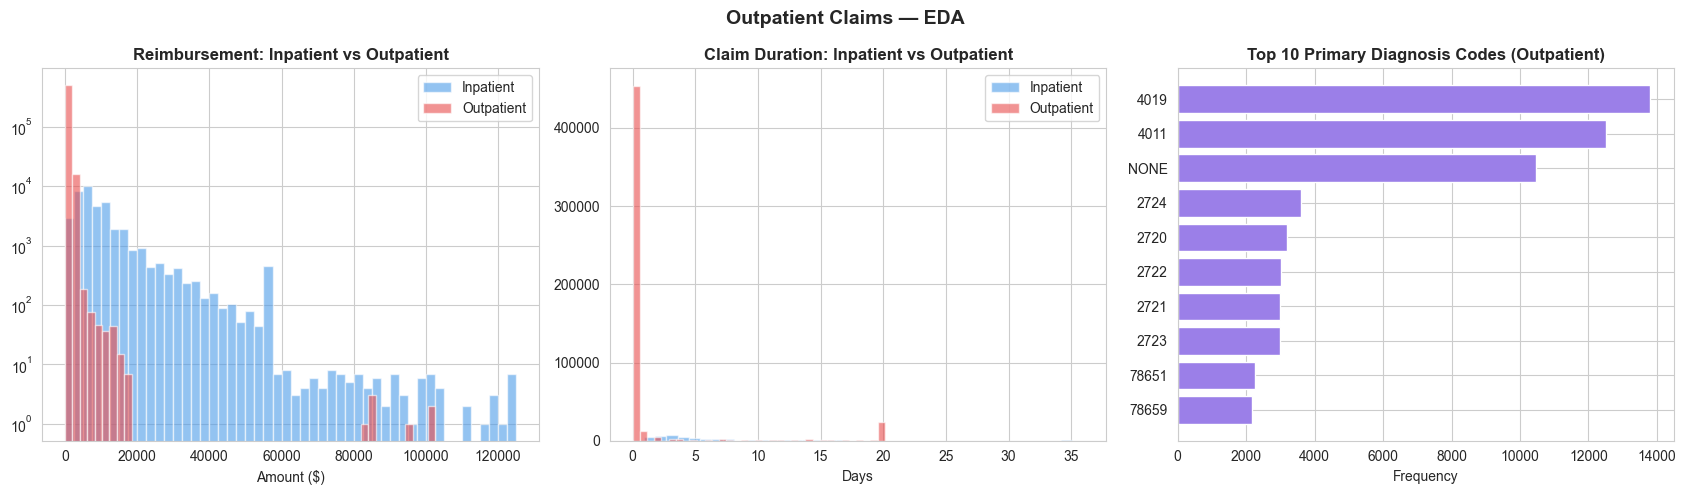

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Reimbursement
axes[0].hist(inpatient_df["InscClaimAmtReimbursed"],  bins=50,
             alpha=0.6, color="#4C9BE8", edgecolor="white", label="Inpatient")
axes[0].hist(outpatient_df["InscClaimAmtReimbursed"], bins=50,
             alpha=0.6, color="#E84C4C", edgecolor="white", label="Outpatient")
axes[0].set_title("Reimbursement: Inpatient vs Outpatient",fontweight="bold")
axes[0].set_xlabel("Amount ($)")
axes[0].set_yscale("log")
axes[0].legend()

# Claim duration comparison
axes[1].hist(inpatient_df["ClaimDuration"],  bins=40, alpha=0.6,
             color="#4C9BE8", label="Inpatient",  edgecolor="white")
axes[1].hist(outpatient_df["ClaimDuration"], bins=40, alpha=0.6,
             color="#E84C4C", label="Outpatient", edgecolor="white")
axes[1].set_title("Claim Duration: Inpatient vs Outpatient", fontweight="bold")
axes[1].set_xlabel("Days")
axes[1].legend()

# Top 10 outpatient diagnosis codes
top_out_diag = outpatient_df["ClmDiagnosisCode_1"].value_counts().head(10)
axes[2].barh(top_out_diag.index[::-1], top_out_diag.values[::-1],
             color="#9B7FE8", edgecolor="white")
axes[2].set_title("Top 10 Primary Diagnosis Codes (Outpatient)", fontweight="bold")
axes[2].set_xlabel("Frequency")

plt.suptitle("Outpatient Claims — EDA", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 1. Reimbursement: Inpatient vs Outpatient (Log Scale)
- The y-axis is on a log scale, which is necessary because the count difference between inpatient and outpatient claims is enormous — outpatient has 517,737 claims vs inpatient's 40,474. Key observations:

  - Outpatient reimbursements are concentrated at very low amounts (`$0`–`$5,000`), reflecting the nature of day visits, check-ups, and minor procedures
  - Inpatient reimbursements are spread across a much wider range (`$5,000`–`$120,000+`), consistent with expensive hospital stays
  - This difference is critical for fraud detection: a provider billing outpatient visits at inpatient-level amounts is an immediate red flag


### 2. Claim Duration: Inpatient vs Outpatient

- Outpatient claims are almost exclusively 0–1 days — the massive spike at day 0 represents same-day visits where the claim start and end date are identical
- Inpatient claims spread across 1–35+ days, reflecting actual hospital stays
- The single outpatient spike at day 20 is suspicious and worth investigating — it could represent a data entry error or a batch of claims that were incorrectly filed as outpatient when they should have been inpatient
- ClaimDuration will behave very differently for inpatient vs outpatient, which is why keeping the ClaimType flag and computing separate averages per type at provider level matters


### 3. Top 10 Primary Diagnosis Codes (Outpatient)
The outpatient diagnosis code landscape is very different from inpatient:

- 4019 (Hypertension, unspecified) and 4011 (Benign essential hypertension) dominate — these are chronic conditions managed through regular outpatient visits, explaining their high frequency
- NONE appearing as the third most common entry confirms that a large number of outpatient claims have no primary diagnosis code recorded — this is a data quality issue specific to the outpatient dataset (10,453 missing values in ClmDiagnosisCode_1)
- Codes 2724, 2720, 2721, 2722, 2723 are all related to disorders of lipid metabolism (cholesterol conditions) — again chronic conditions managed outpatient
- 78651 and 78659 relate to chest pain — high-frequency outpatient presentations

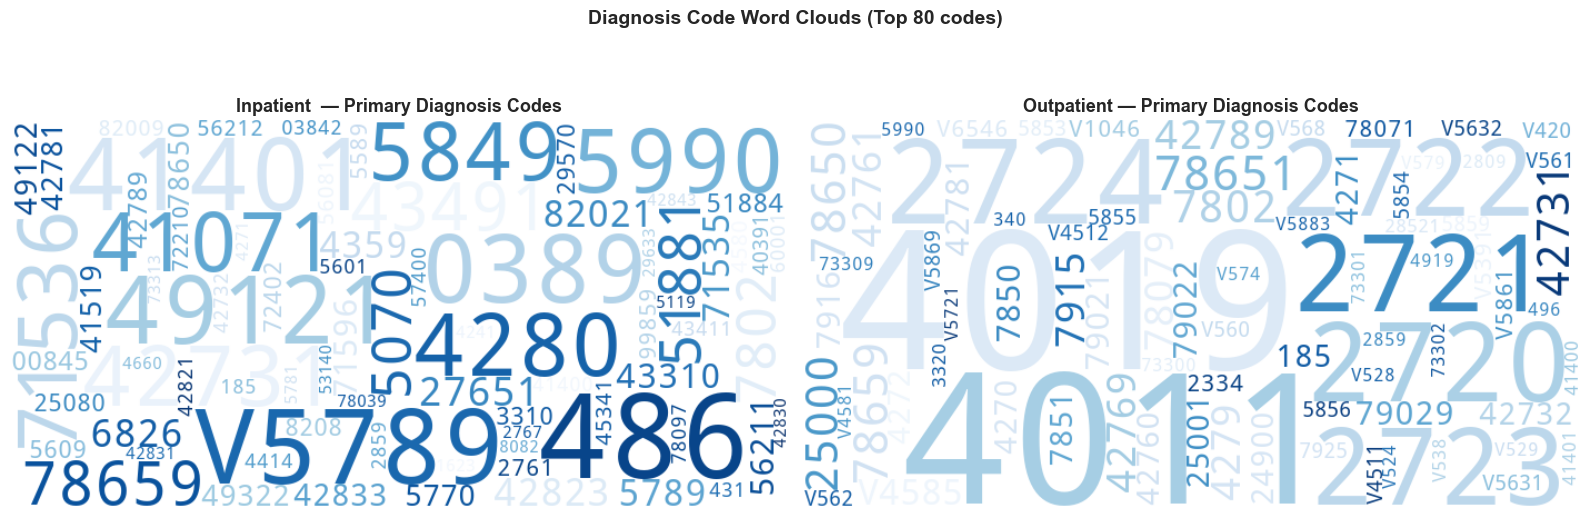

In [43]:
def make_wordcloud(series, title, ax, max_words=80):
    freq = series[series != "NONE"].value_counts().head(max_words).to_dict()
    wc   = WordCloud(width=700, height=350, background_color="white",
                     colormap="Blues", max_words=max_words)
    wc.generate_from_frequencies(freq)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontweight="bold", fontsize=13)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
make_wordcloud(inpatient_df["ClmDiagnosisCode_1"], "Inpatient  — Primary Diagnosis Codes",  axes[0])
make_wordcloud(outpatient_df["ClmDiagnosisCode_1"], "Outpatient — Primary Diagnosis Codes", axes[1])
plt.suptitle("Diagnosis Code Word Clouds (Top 80 codes)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Merging dataframes

### Union Inpatient & Outpatient

In [44]:
inpatient_df["ClaimType"] = "Inpatient"
outpatient_df["ClaimType"] = "Outpatient"

# Align columns: outpatient lacks AdmissionDt/DischargeDt/DiagnosisGroupCode
for col in ["AdmissionDt", "DischargeDt", "DiagnosisGroupCode"]:
    if col not in outpatient_df.columns:
        outpatient_df[col] = np.nan

claims = pd.concat([inpatient_df, outpatient_df], ignore_index=True, sort=False)

print(f"Total claims after union: {len(claims):,}")
print(claims["ClaimType"].value_counts())

Total claims after union: 558,211
ClaimType
Outpatient    517737
Inpatient      40474
Name: count, dtype: int64


### Claims + Beneficiary

In [45]:
claims.columns

Index(['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician',
       'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode',
       'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode',
       'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3',
       'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6',
       'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9',
       'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2',
       'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5',
       'ClmProcedureCode_6', 'ClaimDuration', 'DaysInHospital',
       'SameAttendOper', 'ClaimType'],
      dtype='object')

In [46]:
benf_df.columns

Index(['BeneID', 'DOB', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator',
       'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov',
       'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
       'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
       'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
       'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart',
       'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis',
       'ChronicCond_stroke', 'IPAnnualReimbursementAmt',
       'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt',
       'OPAnnualDeductibleAmt', 'Age', 'IsDead', 'ChronicCondCount'],
      dtype='object')

In [47]:
claims_bene = claims.merge(benf_df, on="BeneID", how="left")

In [48]:
# Row count should match claims exactly (left join preserves all claim rows)
print("Claims rows     :", len(claims))
print("Merged rows     :", len(claims_bene))
print("Should be equal :", len(claims) == len(claims_bene))

Claims rows     : 558211
Merged rows     : 558211
Should be equal : True


In [49]:
claims_bene.columns

Index(['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician',
       'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode',
       'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode',
       'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3',
       'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6',
       'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9',
       'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2',
       'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5',
       'ClmProcedureCode_6', 'ClaimDuration', 'DaysInHospital',
       'SameAttendOper', 'ClaimType', 'DOB', 'DOD', 'Gender', 'Race',
       'RenalDiseaseIndicator', 'State', 'County', 'NoOfMonths_PartACov',
       'NoOfMonths_PartBCov', 'ChronicCond_Alzheimer',
       'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease',
       'ChronicCond_Cancer', '

In [50]:
print(f"After merge with beneficiary: {claims_bene.shape}")

After merge with beneficiary: (558211, 61)


#### Reimbursement-to-deductible ratio  (how much insurer paid vs patient)

In [51]:
claims_bene["ReimbRatio"] = (
    claims_bene["InscClaimAmtReimbursed"] /
    (claims_bene["DeductibleAmtPaid"] + 1)        # +1 avoids divide-by-zero
)

print("\nSample enriched claim:")
print(claims_bene[["BeneID", "ClaimID", "Age","ChronicCondCount", "ReimbRatio"]].head(10))

# At the provider level, a consistently very high average ReimbRatio means the
# provider's patients never pay deductibles while receiving large reimbursements — a known fraud pattern.


Sample enriched claim:
      BeneID   ClaimID  Age  ChronicCondCount  ReimbRatio
0  BENE11001  CLM46614   66                 7   24.321796
1  BENE11001  CLM66048   66                 7    4.677268
2  BENE11001  CLM68358   66                 7    4.677268
3  BENE11011  CLM38412   95                 6    4.677268
4  BENE11014  CLM63689   71                 5    9.354537
5  BENE11017  CLM70950   69                 9    7.483630
6  BENE11018  CLM32075   70                 6    7.483630
7  BENE11028  CLM62376   68                 3    5.612722
8  BENE11031  CLM62784   65                 4    6.548176
9  BENE11034  CLM31519   63                 9   27.128157


#### Top 100 diagnosis and procedure codes

In [52]:
print("Extracting top-100 diagnosis and procedure codes ...")

# Collect all primary diagnosis codes across both inpatient and outpatient
top100_diag = (
    claims_bene["ClmDiagnosisCode_1"]
    .value_counts()
    .drop("NONE", errors="ignore")
    .head(100)
    .index.tolist()
)

top100_proc = (
    claims_bene["ClmProcedureCode_1"]
    .value_counts()
    .drop("NONE", errors="ignore")
    .head(100)
    .index.tolist()
)

print(f"  Top-100 diagnosis codes selected: {len(top100_diag)}")
print(f"  Top-100 procedure codes selected: {len(top100_proc)}")

# Create binary indicator columns at claim level
for code in top100_diag:
    claims_bene[f"Diag_{code}"] = (
        claims_bene["ClmDiagnosisCode_1"] == code).astype(int)

for code in top100_proc:
    claims_bene[f"Proc_{code}"] = (
        claims_bene["ClmProcedureCode_1"] == code).astype(int)

# We extract the 100 most common diagnosis codes and procedure codes
# across all claims. For each provider we then create a binary column:
# "did this provider ever bill this code?" (1/0).
# This captures coding behaviour patterns of fraudulent providers.

print("Code indicator columns created")

Extracting top-100 diagnosis and procedure codes ...


  Top-100 diagnosis codes selected: 100
  Top-100 procedure codes selected: 100
Code indicator columns created


### Provider Level Aggregation

In [53]:
# The label is per-provider, so we must reduce every claim to a
# single row per provider by aggregating claim-level features.

diag_cols_feat = [f"Diag_{c}" for c in top100_diag]
proc_cols_feat = [f"Proc_{c}" for c in top100_proc]

In [54]:
# Core numeric aggregations
agg_dict = {
    # Volume
    "ClaimID"              : "count",       # total claims
    # Financials
    "InscClaimAmtReimbursed": ["sum", "mean", "max"],
    "DeductibleAmtPaid"     : ["sum", "mean"],
    "ReimbRatio"            : "mean",
    # Duration
    "ClaimDuration"         : ["mean", "max"],
    "DaysInHospital"        : ["mean", "sum"],
    # Diversity / complexity
    "Age"            : "mean",
    "ChronicCondCount"      : "mean",
    "SameAttendOper"        : "sum",
    "IsDead"                : "sum",
    # Claim type
    "ClaimType"             : lambda x: (x == "Inpatient").sum(),
}

In [55]:
provider_df = claims_bene.groupby("Provider").agg(agg_dict)

In [56]:
provider_df

ClaimID InscClaimAmtReimbursed                     DeductibleAmtPaid  \
           count                    sum         mean    max               sum   
Provider                                                                        
PRV51001      25                 104640  4185.600000  42000            5340.0   
PRV51003     132                 605670  4588.409091  57000           66286.0   
PRV51004     149                  52170   350.134228   3300             310.0   
PRV51005    1165                 280910   241.124464   4080            3700.0   
PRV51007      72                  33710   468.194444  10000            3264.0   
...          ...                    ...          ...    ...               ...   
PRV57759      28                  10640   380.000000   3300             130.0   
PRV57760      22                   4770   216.818182   1100               0.0   
PRV57761      82                  18470   225.243902   2200             370.0   
PRV57762       1                   1900  1900.000000   1900               0.0   
PRV57763     118                  43610   369.576271   3300             390.0   

                       ReimbRatio ClaimDuration     DaysInHospital       \
                mean         mean          mean max           mean  sum   
Provider                                                                  
PRV51001  213.600000   309.229560      1.440000  14       1.000000   25   
PRV51003  502.166667   250.813814      3.674242  27       2.424242  320   
PRV51004    2.080537   341.265625      1.429530  20       0.000000    0   
PRV51005    3.175966   234.614283      1.088412  20       0.000000    0   
PRV51007   45.333333   202.685705      0.958333  20       0.222222   16   
...              ...          ...           ...  ..            ...  ...   
PRV57759    4.642857   349.303519      2.142857  20       0.000000    0   
PRV57760    0.000000   216.818182      0.318182   7       0.000000    0   
PRV57761    4.512195   223.931266      1.390244  20       0.000000    0   
PRV57762    0.000000  1900.000000      0.000000   0       0.000000    0   
PRV57763    3.305085   344.705313      1.720339  20       0.000000    0   

                Age ChronicCondCount SameAttendOper IsDead ClaimType  
               mean             mean            sum    sum  <lambda>  
Provider                                                              
PRV51001  78.280000         5.560000              0      0         5  
PRV51003  69.553030         4.545455             36      1        62  
PRV51004  71.812081         4.342282             12      1         0  
PRV51005  70.000858         4.335622            131      4         0  
PRV51007  68.791667         4.166667              7      1         3  
...             ...              ...            ...    ...       ...  
PRV57759  73.428571         5.250000              1      0         0  
PRV57760  61.090909         3.500000              6      0         0  
PRV57761  71.402439         4.841463              0      1         0  
PRV57762  67.000000         5.000000              0      0         0  
PRV57763  73.525424         4.593220             19      0         0  

[5410 rows x 16 columns]

In [57]:
provider_df.columns = [
    "_".join(filter(None, col)).strip("_")
    if isinstance(col, tuple) else col
    for col in provider_df.columns
]
provider_df = provider_df.reset_index()

In [58]:
provider_df

,Provider,ClaimID_count,InscClaimAmtReimbursed_sum,InscClaimAmtReimbursed_mean,InscClaimAmtReimbursed_max,DeductibleAmtPaid_sum,DeductibleAmtPaid_mean,ReimbRatio_mean,ClaimDuration_mean,ClaimDuration_max,DaysInHospital_mean,DaysInHospital_sum,Age_mean,ChronicCondCount_mean,SameAttendOper_sum,IsDead_sum,ClaimType_<lambda>
0,PRV51001,25,104640,4185.600000,42000,5340.0,213.600000,309.229560,1.440000,14,1.000000,25,78.280000,5.560000,0,0,5
1,PRV51003,132,605670,4588.409091,57000,66286.0,502.166667,250.813814,3.674242,27,2.424242,320,69.553030,4.545455,36,1,62
2,PRV51004,149,52170,350.134228,3300,310.0,2.080537,341.265625,1.429530,20,0.000000,0,71.812081,4.342282,12,1,0
3,PRV51005,1165,280910,241.124464,4080,3700.0,3.175966,234.614283,1.088412,20,0.000000,0,70.000858,4.335622,131,4,0
4,PRV51007,72,33710,468.194444,10000,3264.0,45.333333,202.685705,0.958333,20,0.222222,16,68.791667,4.166667,7,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5405,PRV57759,28,10640,380.000000,3300,130.0,4.642857,349.303519,2.142857,20,0.000000,0,73.428571,5.250000,1,0,0
5406,PRV57760,22,4770,216.818182,1100,0.0,0.000000,216.818182,0.318182,7,0.000000,0,61.090909,3.500000,6,0,0
5407,PRV57761,82,18470,225.243902,2200,370.0,4.512195,223.931266,1.390244,20,0.000000,0,71.402439,4.841463,0,1,0
5408,PRV57762,1,1900,1900.000000,1900,0.0,0.000000,1900.000000,0.000000,0,0.000000,0,67.000000,5.000000,0,0,0


In [59]:
# Rename for clarity
provider_df = provider_df.rename(columns={
    "ClaimID_count"                         : "TotalClaims",
    "InscClaimAmtReimbursed_sum"            : "TotalReimbursed",
    "InscClaimAmtReimbursed_mean"           : "AvgReimbursed",
    "InscClaimAmtReimbursed_max"            : "MaxReimbursed",
    "DeductibleAmtPaid_sum"                 : "TotalDeductible",
    "DeductibleAmtPaid_mean"                : "AvgDeductible",
    "ReimbRatio_mean"                       : "AvgReimbRatio",
    "ClaimDuration_mean"                    : "AvgClaimDuration",
    "ClaimDuration_max"                     : "MaxClaimDuration",
    "DaysInHospital_mean"                   : "AvgDaysInHospital",
    "DaysInHospital_sum"                    : "TotalDaysInHospital",
    "Age_mean"                       : "AvgPatientAge",
    "ChronicCondCount_mean"                 : "AvgChronicConds",
    "SameAttendOper_sum"                    : "SameAttendOperCount",
    "IsDead_sum"                            : "DeceasedPatientCount",
    "ClaimType_<lambda>"                    : "InpatientClaimCount",
})

In [60]:
# Unique-count features require separate groupby
uniq = claims_bene.groupby("Provider").agg(
    UniquePatients      = ("BeneID",               "nunique"),
    UniqueAttendPhys    = ("AttendingPhysician",    "nunique"),
    UniqueOperPhys      = ("OperatingPhysician",    "nunique"),
    UniqueDiagnoses     = ("ClmDiagnosisCode_1",    "nunique"),
    UniqueProcedures    = ("ClmProcedureCode_1",    "nunique"),
).reset_index()

In [61]:
uniq

,Provider,UniquePatients,UniqueAttendPhys,UniqueOperPhys,UniqueDiagnoses,UniqueProcedures
0,PRV51001,24,14,5,24,3
1,PRV51003,117,44,7,115,33
2,PRV51004,138,38,19,129,1
3,PRV51005,495,6,6,810,1
4,PRV51007,58,10,5,71,2
...,...,...,...,...,...,...
5405,PRV57759,24,1,1,27,1
5406,PRV57760,9,3,2,20,1
5407,PRV57761,67,2,5,81,1
5408,PRV57762,1,1,0,1,1


In [62]:
provider_df = provider_df.merge(uniq, on="Provider", how="left")

In [63]:
provider_df

,Provider,TotalClaims,TotalReimbursed,AvgReimbursed,MaxReimbursed,TotalDeductible,AvgDeductible,AvgReimbRatio,AvgClaimDuration,MaxClaimDuration,...,AvgPatientAge,AvgChronicConds,SameAttendOperCount,DeceasedPatientCount,InpatientClaimCount,UniquePatients,UniqueAttendPhys,UniqueOperPhys,UniqueDiagnoses,UniqueProcedures
0,PRV51001,25,104640,4185.600000,42000,5340.0,213.600000,309.229560,1.440000,14,...,78.280000,5.560000,0,0,5,24,14,5,24,3
1,PRV51003,132,605670,4588.409091,57000,66286.0,502.166667,250.813814,3.674242,27,...,69.553030,4.545455,36,1,62,117,44,7,115,33
2,PRV51004,149,52170,350.134228,3300,310.0,2.080537,341.265625,1.429530,20,...,71.812081,4.342282,12,1,0,138,38,19,129,1
3,PRV51005,1165,280910,241.124464,4080,3700.0,3.175966,234.614283,1.088412,20,...,70.000858,4.335622,131,4,0,495,6,6,810,1
4,PRV51007,72,33710,468.194444,10000,3264.0,45.333333,202.685705,0.958333,20,...,68.791667,4.166667,7,1,3,58,10,5,71,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5405,PRV57759,28,10640,380.000000,3300,130.0,4.642857,349.303519,2.142857,20,...,73.428571,5.250000,1,0,0,24,1,1,27,1
5406,PRV57760,22,4770,216.818182,1100,0.0,0.000000,216.818182,0.318182,7,...,61.090909,3.500000,6,0,0,9,3,2,20,1
5407,PRV57761,82,18470,225.243902,2200,370.0,4.512195,223.931266,1.390244,20,...,71.402439,4.841463,0,1,0,67,2,5,81,1
5408,PRV57762,1,1900,1900.000000,1900,0.0,0.000000,1900.000000,0.000000,0,...,67.000000,5.000000,0,0,0,1,1,0,1,1


In [64]:
provider_df.columns

Index(['Provider', 'TotalClaims', 'TotalReimbursed', 'AvgReimbursed',
       'MaxReimbursed', 'TotalDeductible', 'AvgDeductible', 'AvgReimbRatio',
       'AvgClaimDuration', 'MaxClaimDuration', 'AvgDaysInHospital',
       'TotalDaysInHospital', 'AvgPatientAge', 'AvgChronicConds',
       'SameAttendOperCount', 'DeceasedPatientCount', 'InpatientClaimCount',
       'UniquePatients', 'UniqueAttendPhys', 'UniqueOperPhys',
       'UniqueDiagnoses', 'UniqueProcedures'],
      dtype='object')

In [65]:

# Derived ratio features
provider_df["OutpatientClaimCount"]  = (
    provider_df["TotalClaims"] - provider_df["InpatientClaimCount"])
provider_df["InpatientRatio"]        = (
    provider_df["InpatientClaimCount"] / provider_df["TotalClaims"])
provider_df["PatientsPerClaim"]      = (
    provider_df["UniquePatients"] / provider_df["TotalClaims"])
provider_df["PhysiciansPerClaim"]    = (
    provider_df["UniqueAttendPhys"] / provider_df["TotalClaims"])
provider_df["SameAttendOperRate"]    = (
    provider_df["SameAttendOperCount"] / provider_df["TotalClaims"])
provider_df["DeceasedPatientRate"]   = (
    provider_df["DeceasedPatientCount"] / provider_df["UniquePatients"])

In [66]:
# Binary code features: did this provider EVER bill each code?
code_agg = claims_bene.groupby("Provider")[diag_cols_feat + proc_cols_feat].max()
provider_df = provider_df.merge(code_agg.reset_index(), on="Provider", how="left")

print(f"\n✓ Provider-level DataFrame: {provider_df.shape}")
print(f"  Core numeric features : ~22")
print(f"  Diagnosis code features: {len(diag_cols_feat)}")
print(f"  Procedure code features: {len(proc_cols_feat)}")
print(f"  Total features         : {provider_df.shape[1] - 1}")


✓ Provider-level DataFrame: (5410, 228)
  Core numeric features : ~22
  Diagnosis code features: 100
  Procedure code features: 100
  Total features         : 227


In [67]:
provider_df

,Provider,TotalClaims,TotalReimbursed,AvgReimbursed,MaxReimbursed,TotalDeductible,AvgDeductible,AvgReimbRatio,AvgClaimDuration,MaxClaimDuration,...,Proc_8944,Proc_3249,Proc_9394,Proc_9961,Proc_5185,Proc_80,Proc_6859,Proc_3611,Proc_3771,Proc_8877
0,PRV51001,25,104640,4185.600000,42000,5340.0,213.600000,309.229560,1.440000,14,...,0,0,0,0,0,0,0,0,0,0
1,PRV51003,132,605670,4588.409091,57000,66286.0,502.166667,250.813814,3.674242,27,...,0,0,1,0,0,0,0,0,0,0
2,PRV51004,149,52170,350.134228,3300,310.0,2.080537,341.265625,1.429530,20,...,0,0,0,0,0,0,0,0,0,0
3,PRV51005,1165,280910,241.124464,4080,3700.0,3.175966,234.614283,1.088412,20,...,0,0,0,0,0,0,0,0,0,0
4,PRV51007,72,33710,468.194444,10000,3264.0,45.333333,202.685705,0.958333,20,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5405,PRV57759,28,10640,380.000000,3300,130.0,4.642857,349.303519,2.142857,20,...,0,0,0,0,0,0,0,0,0,0
5406,PRV57760,22,4770,216.818182,1100,0.0,0.000000,216.818182,0.318182,7,...,0,0,0,0,0,0,0,0,0,0
5407,PRV57761,82,18470,225.243902,2200,370.0,4.512195,223.931266,1.390244,20,...,0,0,0,0,0,0,0,0,0,0
5408,PRV57762,1,1900,1900.000000,1900,0.0,0.000000,1900.000000,0.000000,0,...,0,0,0,0,0,0,0,0,0,0


### Merge with labels

In [68]:
labels_df["FraudLabel"] = (labels_df["PotentialFraud"] == "Yes").astype(int)

In [69]:
final_df = labels_df.merge(provider_df, on="Provider", how="left")

print("Final DataFrame shape :", final_df.shape)
print("Fraud label distribution:")
print(final_df["FraudLabel"].value_counts())
print(final_df["FraudLabel"].value_counts(normalize=True).round(3))

Final DataFrame shape : (5410, 230)
Fraud label distribution:
FraudLabel
0    4904
1     506
Name: count, dtype: int64
FraudLabel
0    0.906
1    0.094
Name: proportion, dtype: float64


## Provider Level Null Analysis

In [70]:
null_final = final_df.isnull().sum()
null_final = null_final[null_final > 0]
null_pct_f = (null_final / len(final_df) * 100).round(2)

if len(null_final) == 0:
    print("✓ No missing values in final provider-level DataFrame!")
else:
    print("Remaining missing values:")
    print(pd.DataFrame({"Missing": null_final, "Missing%": null_pct_f}))

✓ No missing values in final provider-level DataFrame!


## Provider Level EDA

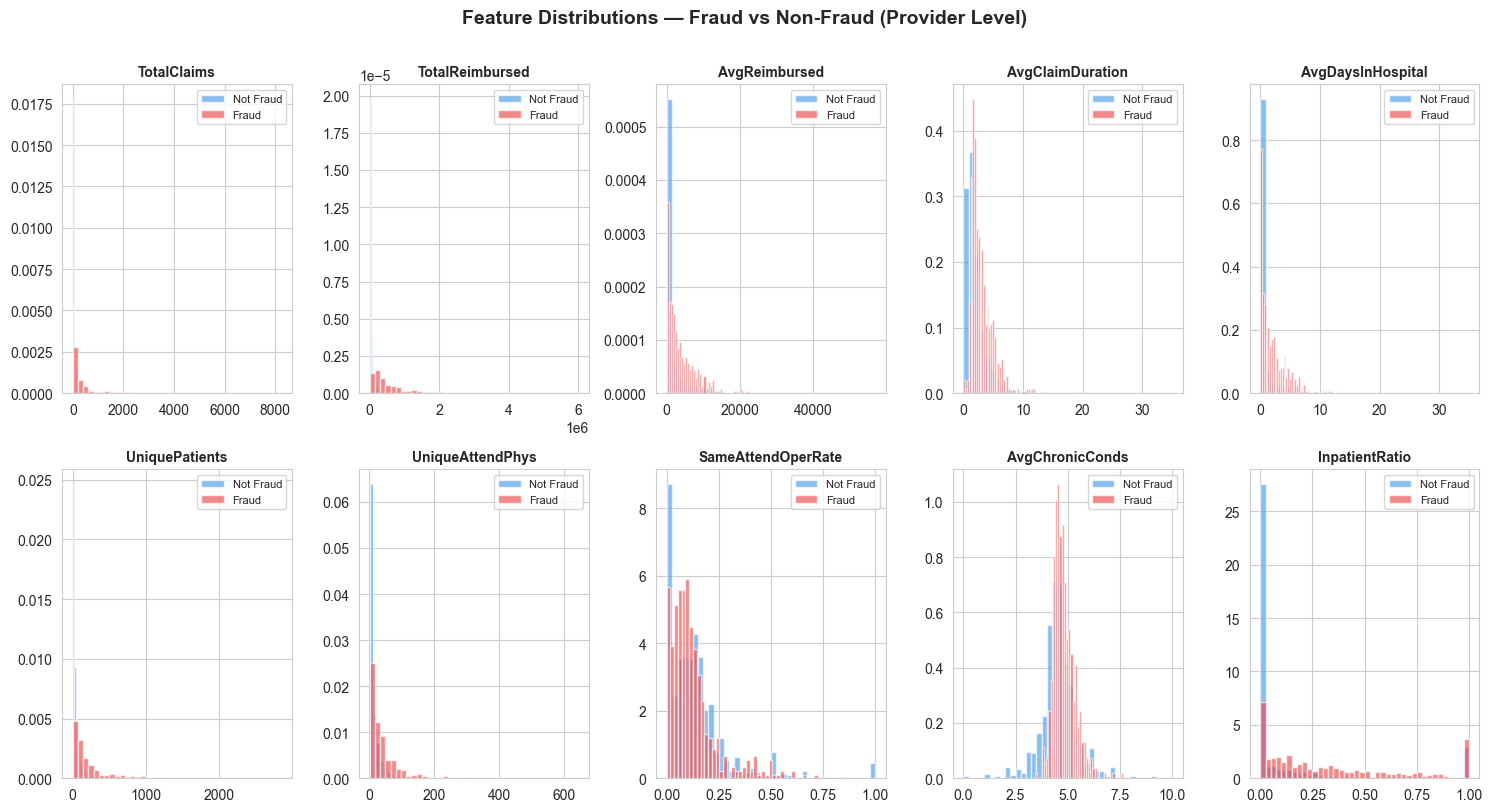

In [71]:
CORE_FEATURES = [
    "TotalClaims", "TotalReimbursed", "AvgReimbursed",
    "AvgClaimDuration", "AvgDaysInHospital",
    "UniquePatients", "UniqueAttendPhys",
    "SameAttendOperRate", "AvgChronicConds", "InpatientRatio",
]

fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(CORE_FEATURES):
    fraud_data     = final_df.loc[final_df["FraudLabel"] == 1, col].dropna()
    non_fraud_data = final_df.loc[final_df["FraudLabel"] == 0, col].dropna()

    axes[i].hist(non_fraud_data, bins=40, alpha=0.65, density=True,
                 color="#4C9BE8", label="Not Fraud", edgecolor="white")
    axes[i].hist(fraud_data,     bins=40, alpha=0.65, density=True,
                 color="#E84C4C", label="Fraud",     edgecolor="white")

    axes[i].set_title(col.replace("_", " "), fontweight="bold", fontsize=10)
    axes[i].legend(fontsize=8)

plt.suptitle("Feature Distributions — Fraud vs Non-Fraud (Provider Level)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

1. Total Claims
- The red (Fraud) distribution has a noticeably longer right tail — fraudulent providers tend to submit significantly more claims. High claim volume is a fraud signal because fraudulent providers maximise billing by filing as many claims as possible.

2. TotalReimbursed
- Fraudulent providers receive dramatically higher total reimbursements — confirming that billing inflation is the core fraud mechanism.

3. AvgReimbursed
- Similar pattern to TotalReimbursed but per claim. Fraudulent providers bill higher amounts per individual claim on average — consistent with upcoding (billing for more expensive procedures than were actually performed).

4. AvgClaimDuration
- the fraud distribution has a heavier right tail — fraudulent providers keep claims open longer on average. Longer claim durations can indicate billing manipulation where the provider extends the billing window artificially.

5. AvgDaysInHospital
- The blue distribution is extremely concentrated near 0 days — legitimate providers have many outpatient-only patients with no hospital stays. The red (Fraud) distribution spreads much further right, showing fraudulent providers consistently have longer average hospital stays across their patient base. This is a classic fraud pattern — admitting patients unnecessarily or prolonging stays to increase billing.

6. UniquePatients
- Legitimate providers cluster at very low patient counts. Fraudulent providers show a wider spread toward higher unique patient counts — they cast a wider net, billing for more unique patients to maximise total reimbursements. This also relates to phantom billing — fabricating visits for patients who never actually came.

7. UniqueAttendPhys
- Fraudulent providers use more unique attending physicians on average. This can indicate a network of colluding doctors all billing under the same provider, or fabricated physician credentials being used to inflate claim counts.

8. SameAttendOperRate
- This is a very strong fraud signal. The blue distribution spikes sharply near 0 — most legitimate providers rarely have the same doctor acting as both attending and operating physician. The red distribution is much more spread out toward higher rates — fraudulent providers frequently list the same physician in both roles, a hallmark of phantom billing where no actual procedure was performed.

9. AvgChronicConds
- Both distributions overlap significantly here and peak around 4–5 chronic conditions, suggesting this feature alone may not strongly differentiate fraud from non-fraud. However fraudulent providers show a slightly wider spread — they may selectively target patients with more chronic conditions to justify complex and expensive treatment billing.

10. InpatientRatio
The blue distribution spikes sharply near 0 — most legitimate providers are predominantly outpatient with very few inpatient admissions. The red distribution is noticeably more spread across higher inpatient ratios — fraudulent providers submit a higher proportion of inpatient claims relative to outpatient. This makes sense because inpatient claims reimburse at much higher rates than outpatient visits, making them the preferred vehicle for fraud.

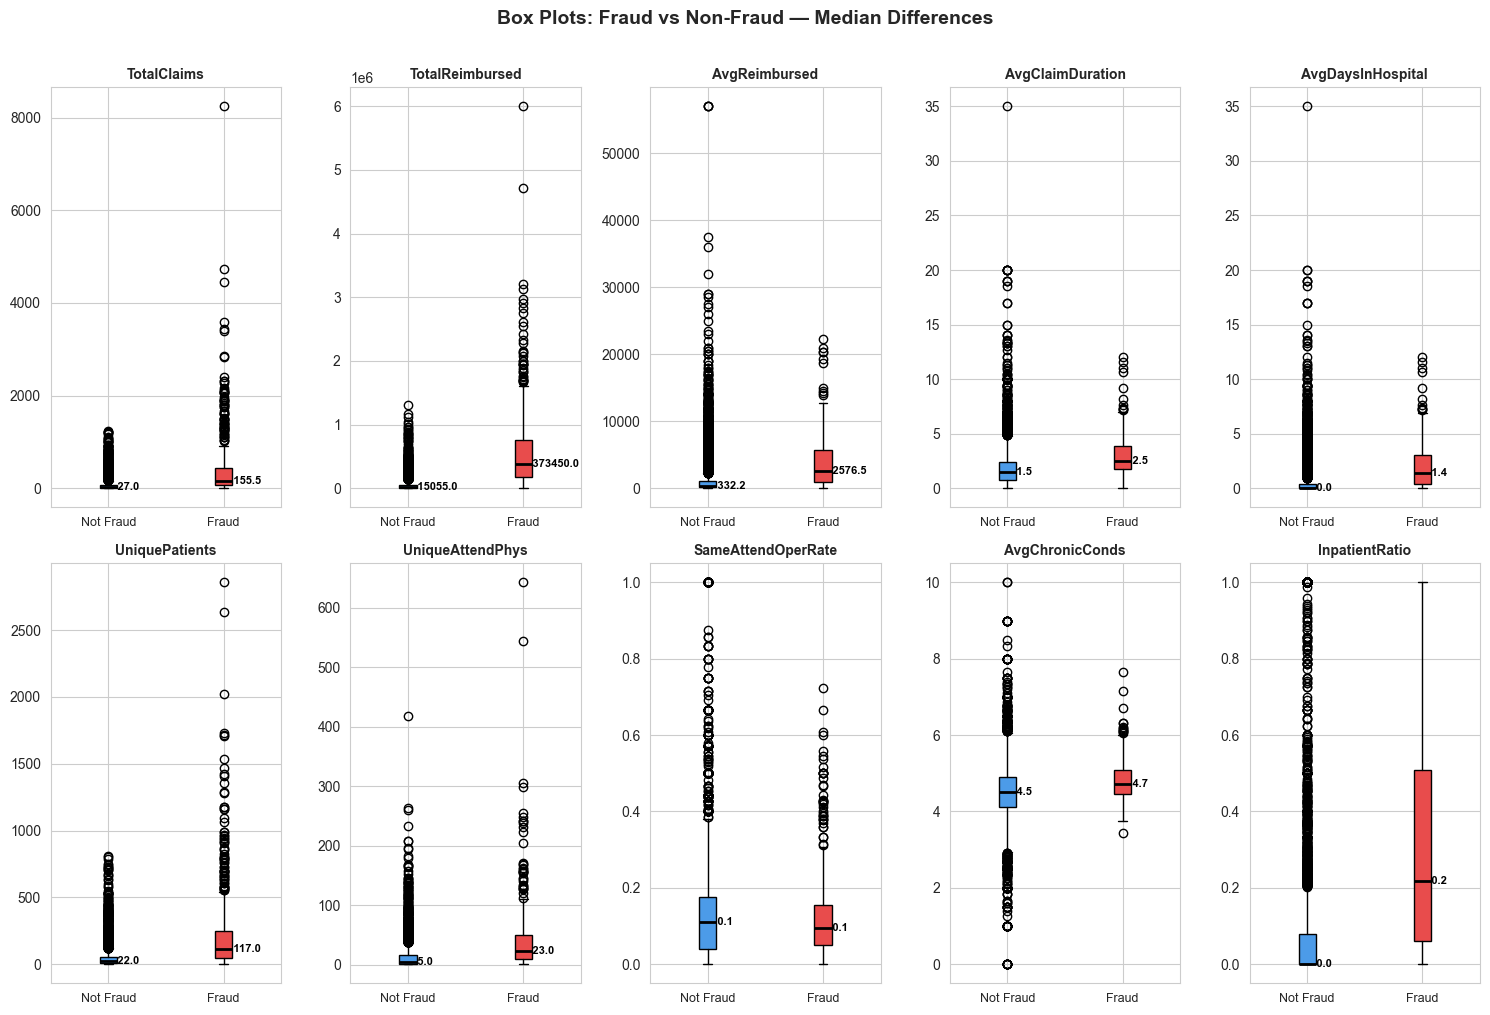

In [72]:
fig, axes = plt.subplots(2, 5, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(CORE_FEATURES):
    plot_data  = final_df[[col, "FraudLabel"]].copy()
    plot_data["Class"] = plot_data["FraudLabel"].map({0:"Not Fraud", 1:"Fraud"})

    groups = [plot_data.loc[plot_data["FraudLabel"] == 0, col].dropna(),
              plot_data.loc[plot_data["FraudLabel"] == 1, col].dropna()]

    bp = axes[i].boxplot(groups, patch_artist=True, notch=False,
                         medianprops=dict(color="black", linewidth=2))
    bp["boxes"][0].set_facecolor("#4C9BE8")
    bp["boxes"][1].set_facecolor("#E84C4C")
    axes[i].set_xticks([1, 2])
    axes[i].set_xticklabels(["Not Fraud", "Fraud"], fontsize=9)
    axes[i].set_title(col.replace("_", " "), fontweight="bold", fontsize=10)

    # Annotate with median values
    for j, grp in enumerate(groups):
        axes[i].text(j + 1, grp.median(), f"   {grp.median():.1f}",
                     va="center", fontsize=8, color="black", fontweight="bold")

plt.suptitle("Box Plots: Fraud vs Non-Fraud — Median Differences",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

1. Total Claims
- Fraudulent providers submit ~5.7x more claims than legitimate ones. The fraud box is noticeably taller showing higher variance among fraudulent providers. Outliers reach 8,000+ claims — some fraudulent providers are extremely aggressive billers. High claim volume is a core fraud strategy — the more claims filed, the more money collected.

2. TotalReimbursed
- The most dramatic difference in the entire grid — fraudulent providers collect ~25x more total reimbursement. The fraud box sits dramatically higher with a much larger IQR, and outliers reach $6,000,000+. This is the single strongest fraud signal in the dataset.

3. AvgReimbursed
- Fraudulent providers bill ~7.8x more per individual claim on average. The legitimate provider box is extremely compressed near zero while the fraud box is taller and higher. This confirms upcoding — fraudulent providers consistently bill for more expensive procedures than were actually performed on each individual claim.

4. AvgClaimDuration
- Fraudulent providers keep claims open ~1 day longer on average. While the absolute difference seems small.

5. AvgDaysinHospital
- Legitimate providers have a median of 0 hospital days — the majority of their patients are outpatient only and never get admitted. Fraudulent providers show a median of 1.4 days with a much larger box and outliers reaching 35 days. This confirms two fraud patterns simultaneously — unnecessary admissions and prolonged stays.

6. UniquePatients
- Fraudulent providers treat ~5.3x more unique patients at the median. The legitimate provider box is very compressed near zero while the fraud box is taller with many outliers reaching 2,500+ patients. This is consistent with two fraud patterns — phantom billing (fabricating visits for patients who never attended) and patient mills (recruiting large numbers of patients purely for billing purposes rather than genuine medical need).

7. UniqueAttendPhys
- Fraudulent providers have ~4.6x more unique attending physicians on their claims. The legitimate provider box is almost flat near the bottom while the fraud box is significantly taller. This suggests physician networks — organised groups of colluding doctors all billing under the same provider — or fabricated physician

8. SameAttendOperRate
- A subset of highly fraudulent providers show extremely high rates of the same physician acting as both attending and operating physician — a hallmark of phantom billing. The median alone is misleading here; the spread and outliers carry the signal.

9. AvgChronicConds
- The smallest difference in the entire plot — only 0.2 conditions separating the medians. Both boxes heavily overlap with similar heights and ranges. Chronic condition count is essentially the same for patients of both fraudulent and legitimate providers, confirming that fraudulent providers target similarly sick patient populations to justify expensive treatments. This feature will likely have very low predictive importance in the final model.

10. InpatientRatio
- Legitimate providers have a median inpatient ratio of exactly 0 — meaning more than half of all legitimate providers submit exclusively outpatient claims and never bill for a single inpatient admission. Fraudulent providers show a median of 0.2 with a dramatically wider and taller red box extending all the way to 1.0 — some fraudulent providers submit exclusively inpatient claims. Since inpatient claims reimburse at significantly higher rates than outpatient visits, fraudulent providers deliberately inflate the proportion of inpatient billing to maximise revenue per patient.

### Core Features Correlation Matrix

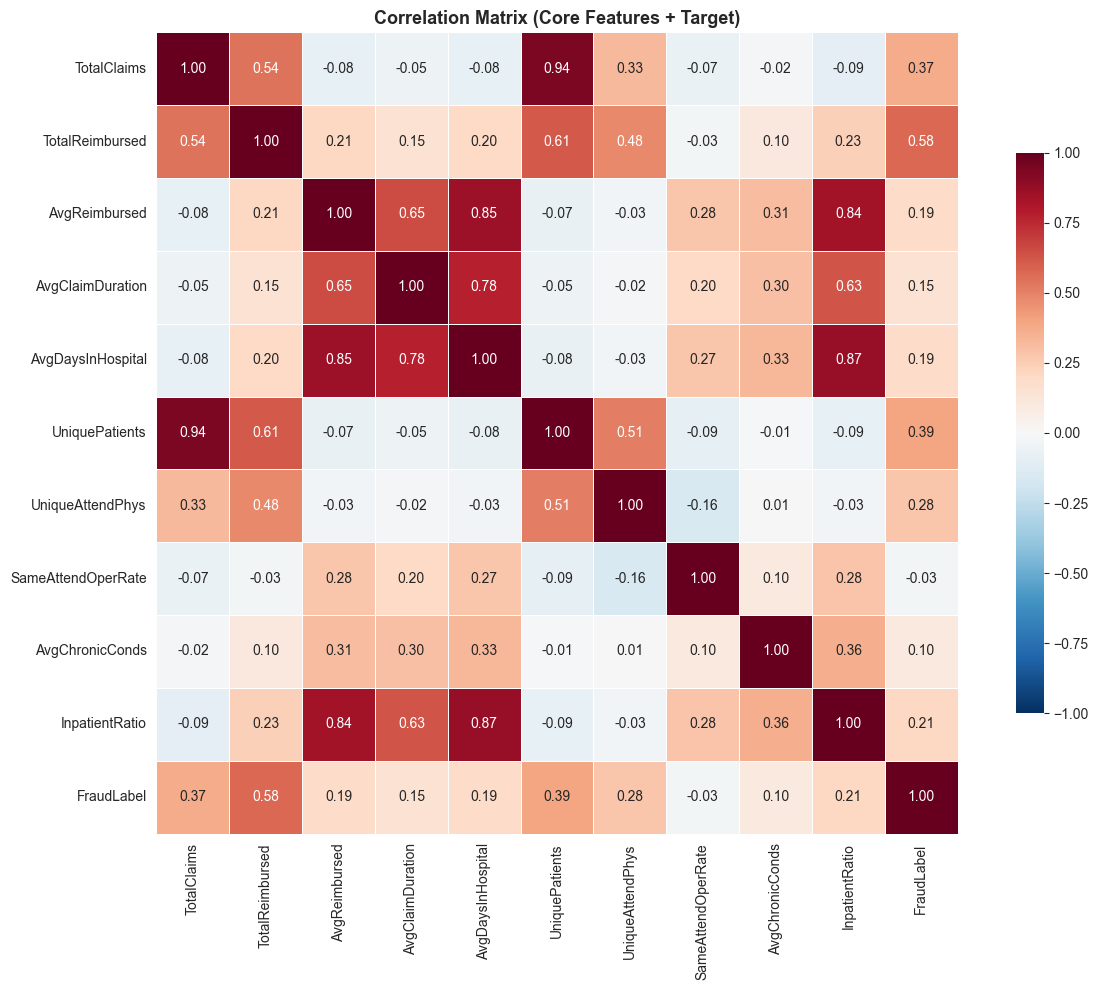

In [73]:
corr_cols = CORE_FEATURES + ["FraudLabel"]
corr_matrix = final_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True,
    cbar_kws={"shrink": 0.7},
    ax=ax
)
ax.set_title("Correlation Matrix (Core Features + Target)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Top Features correlated with FraudLabel (last row/column)
- TotalReimbursed    → 0.58  # strongest fraud predictor
- TotalClaims        → 0.37  
- UniquePatients     → 0.39  
- UniqueAttendPhys   → 0.28  
- InpatientRatio     → 0.21  
- AvgDaysInHospital  → 0.19  
- AvgReimbursed      → 0.19  
- AvgClaimDuration   → 0.15  
- AvgChronicConds    → 0.10  
- SameAttendOperRate → -0.03  # almost no linear correlation

In [74]:
profile = (
    final_df
    .groupby("FraudLabel")[CORE_FEATURES]
    .median()
    .T
    .rename(columns={0: "Not Fraud (median)", 1: "Fraud (median)"})
)
profile["Ratio (Fraud/Not Fraud)"] = (
    profile["Fraud (median)"] / profile["Not Fraud (median)"].replace(0, np.nan)
).round(2)

print("=" * 65)
print("FRAUD PROVIDER PROFILE  —  Median Feature Comparison")
print("=" * 65)
print(profile.to_string())

FRAUD PROVIDER PROFILE  —  Median Feature Comparison
FraudLabel          Not Fraud (median)  Fraud (median)  Ratio (Fraud/Not Fraud)
TotalClaims                  27.000000      155.500000                     5.76
TotalReimbursed           15055.000000   373450.000000                    24.81
AvgReimbursed               332.192088     2576.480084                     7.76
AvgClaimDuration              1.512224        2.478220                     1.64
AvgDaysInHospital             0.000000        1.361804                      NaN
UniquePatients               22.000000      117.000000                     5.32
UniqueAttendPhys              5.000000       23.000000                     4.60
SameAttendOperRate            0.111111        0.093780                     0.84
AvgChronicConds               4.500000        4.716257                     1.05
InpatientRatio                0.000000        0.217677                      NaN


In [75]:
print("=" * 65)
print("FINAL DATASET READY FOR MODELLING")
print("=" * 65)
print(f"Shape            : {final_df.shape}")
print(f"Providers        : {len(final_df):,}")
print(f"Fraud providers  : {final_df['FraudLabel'].sum():,}  "
      f"({final_df['FraudLabel'].mean()*100:.1f}%)")
print(f"Features (total) : {final_df.shape[1] - 3}")  # minus Provider, PotentialFraud, FraudLabel
print()

FINAL DATASET READY FOR MODELLING
Shape            : (5410, 230)
Providers        : 5,410
Fraud providers  : 506  (9.4%)
Features (total) : 227



# Train-Test Split

In [76]:
# Feature type breakdown
n_code_feat  = len(diag_cols_feat) + len(proc_cols_feat)
n_core_feat  = len(CORE_FEATURES)
n_ratio_feat = 6
print(f"  Core numeric          : {n_core_feat}")
print(f"  Ratio/derived         : {n_ratio_feat}")
print(f"  Top-100 diag codes    : {len(diag_cols_feat)}")
print(f"  Top-100 proc codes    : {len(proc_cols_feat)}")
print()

  Core numeric          : 10
  Ratio/derived         : 6
  Top-100 diag codes    : 100
  Top-100 proc codes    : 100



We will start with just the 10 core features first — get a baseline model working, then add code features later to see if they improve performance.

In [77]:
CORE_FEATURES

['TotalClaims',
 'TotalReimbursed',
 'AvgReimbursed',
 'AvgClaimDuration',
 'AvgDaysInHospital',
 'UniquePatients',
 'UniqueAttendPhys',
 'SameAttendOperRate',
 'AvgChronicConds',
 'InpatientRatio']

In [78]:
X = final_df[CORE_FEATURES]
y = final_df["FraudLabel"]

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [80]:
print("Train-Test Split Results:")
print(f"  X_train : {X_train.shape}  -  {len(X_train):,} providers for training")
print(f"  X_test  : {X_test.shape}   -  {len(X_test):,}  providers for testing")
print()
print("Fraud ratio check (stratify working correctly):")
print(f"  Original  : {y.mean()*100:.1f}% fraud")
print(f"  Train set : {y_train.mean()*100:.1f}% fraud  - should match original")
print(f"  Test  set : {y_test.mean()*100:.1f}% fraud  - should match original")
print()

Train-Test Split Results:
  X_train : (4328, 10)  -  4,328 providers for training
  X_test  : (1082, 10)   -  1,082  providers for testing

Fraud ratio check (stratify working correctly):
  Original  : 9.4% fraud
  Train set : 9.4% fraud  - should match original
  Test  set : 9.3% fraud  - should match original



In [81]:
# Count fraud cases in each set
train_fraud = y_train.sum()
test_fraud  = y_test.sum()
print(f"  Fraud in train : {train_fraud} providers")
print(f"  Fraud in test  : {test_fraud}  providers")

  Fraud in train : 405 providers
  Fraud in test  : 101  providers


# Feature Scaling

In [82]:
scaler = StandardScaler()

In [83]:
# Fit on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Apply the SAME scaler (same mean, same std) to test data
X_test_scaled  = scaler.transform(X_test)

In [84]:
# Convert back to DataFrames with column names (easier to inspect)
X_train_scaled = pd.DataFrame(X_train_scaled,
                               columns=CORE_FEATURES,
                               index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,
                               columns=CORE_FEATURES,
                               index=X_test.index)

In [85]:
print("Scaling Results:")
print("\nBefore scaling (X_train stats):")
print(X_train[["TotalReimbursed", "InpatientRatio", "TotalClaims"]].describe().round(2))

print("\nAfter scaling (X_train_scaled stats):")
print(X_train_scaled[["TotalReimbursed", "InpatientRatio", "TotalClaims"]].describe().round(2))

Scaling Results:

Before scaling (X_train stats):
       TotalReimbursed  InpatientRatio  TotalClaims
count          4328.00         4328.00      4328.00
mean          99555.50            0.15        98.07
std          259764.97            0.29       259.27
min               0.00            0.00         1.00
25%            4477.50            0.00        10.00
50%           19480.00            0.00        31.00
75%           85002.50            0.13        85.00
max         5996050.00            1.00      8240.00

After scaling (X_train_scaled stats):
       TotalReimbursed  InpatientRatio  TotalClaims
count          4328.00         4328.00      4328.00
mean             -0.00            0.00        -0.00
std               1.00            1.00         1.00
min              -0.38           -0.50        -0.37
25%              -0.37           -0.50        -0.34
50%              -0.31           -0.50        -0.26
75%              -0.06           -0.04        -0.05
max              22.70     

# Class Imbalance with SMOTE

Our training set has ~3,896 Not Fraud providers  (90.6%) and ~  404 Fraud providers  (9.4%), so this 10:1 imbalance is a BIG problem for the model. If I don't handle the imbalance, then the model learns: "if I predict NOT FRAUD for everyone, I am correct 90.6% of the time" — 90.6% accuracy! but it catches ZERO fraud cases which is completely useless.

SMOTE — Synthetic Minority Oversampling TEchnique. SMOTE creates SYNTHETIC (artificial) fraud provider rows to balance the classes. It does NOT just copy existing fraud rows — it creates NEW ones by:
- Take a real fraud provider row (the minority class)
- Find its nearest neighbours (other fraud providers)
- Create a new synthetic point BETWEEN them

After SMOTE, training set becomes roughly 50/50.

In [86]:
print("Before SMOTE:")
print(f"  Training set size : {len(X_train_scaled):,}")
print(f"  Not Fraud         : {(y_train == 0).sum():,} ({(y_train == 0).mean()*100:.1f}%)")
print(f"  Fraud             : {(y_train == 1).sum():,} ({(y_train == 1).mean()*100:.1f}%)")

Before SMOTE:
  Training set size : 4,328
  Not Fraud         : 3,923 (90.6%)
  Fraud             : 405 (9.4%)


In [87]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

In [88]:
print("\nAfter SMOTE:")
print(f"  Training set size : {len(X_train_resampled):,}")
print(f"  Not Fraud         : {(y_train_resampled == 0).sum():,} ({(y_train_resampled == 0).mean()*100:.1f}%)")
print(f"  Fraud             : {(y_train_resampled == 1).sum():,} ({(y_train_resampled == 1).mean()*100:.1f}%)")
print()


After SMOTE:
  Training set size : 7,846
  Not Fraud         : 3,923 (50.0%)
  Fraud             : 3,923 (50.0%)



## WHY NOT just use class_weight='balanced' instead of SMOTE?

- class_weight='balanced' - tells the model to penalise mistakes on minority class more heavily during training. Simpler, no new rows created.

- SMOTE - actually creates new data points, giving the model more examples to learn from. We will try BOTH and compare. First we use SMOTE.

# Train Baseline Model

In [89]:
lr_baseline = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_baseline.fit(X_train_resampled, y_train_resampled)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [90]:
print("Baseline Logistic Regression trained")
print(f"  Trained on : {len(X_train_resampled):,} samples (after SMOTE)")
print(f"  Features   : {len(CORE_FEATURES)}")
print()

Baseline Logistic Regression trained
  Trained on : 7,846 samples (after SMOTE)
  Features   : 10



In [91]:
coef_df = pd.DataFrame({
    "Feature"    : CORE_FEATURES,
    "Coefficient": lr_baseline.coef_[0]
}).sort_values("Coefficient", ascending=False)

print("Feature Coefficients (higher = stronger fraud indicator):")
print(coef_df.to_string(index=False))
print("\nLarger absolute value = stronger influence on prediction")

Feature Coefficients (higher = stronger fraud indicator):
           Feature  Coefficient
   TotalReimbursed     3.186424
       TotalClaims     2.527898
  UniqueAttendPhys     0.304843
 AvgDaysInHospital     0.262055
   AvgChronicConds     0.148241
     AvgReimbursed     0.117899
  AvgClaimDuration     0.006016
    InpatientRatio    -0.094827
SameAttendOperRate    -0.198574
    UniquePatients    -2.198914

Larger absolute value = stronger influence on prediction


# Basic Predictions

In [92]:
y_pred = lr_baseline.predict(X_test_scaled)

In [93]:
y_proba = lr_baseline.predict_proba(X_test_scaled)[:, 1]

In [94]:
print("Prediction Examples (first 10 test providers):")
print(f"{'Actual':<10} {'Predicted':<12} {'P(Fraud)':<12}")
print("-" * 35)
for actual, pred, prob in zip(y_test[:10], y_pred[:10], y_proba[:10]):
    flag = " ← FRAUD" if actual == 1 else ""
    print(f"{actual:<10} {pred:<12} {prob:.4f}{flag}")

Prediction Examples (first 10 test providers):
Actual     Predicted    P(Fraud)    
-----------------------------------
0          0            0.0400
0          0            0.0963
0          0            0.1432
0          0            0.1445
0          0            0.1176
0          0            0.0915
0          0            0.1557
0          0            0.2452
0          1            0.6978
0          0            0.2868


# Confusion Matrix

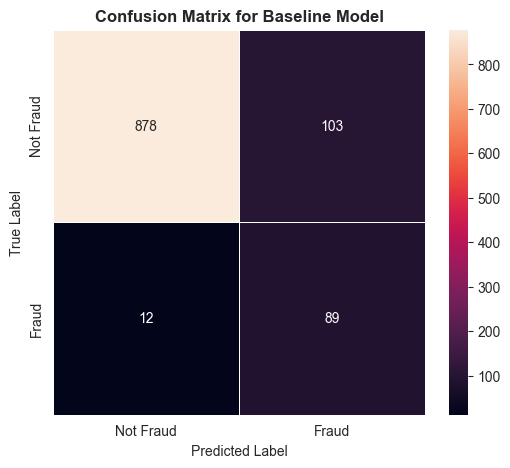

In [95]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Not Fraud", "Fraud"],
            yticklabels=["Not Fraud", "Fraud"],
            linewidths=0.5, linecolor="white")
plt.title("Confusion Matrix for Baseline Model", fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

From the confusion matrix, we can see:

- **True Negatives (TN):** 878 instances were correctly predicted as 'Not Fraud'.
- **False Positives (FP):** 103 instances were incorrectly predicted as 'Fraud' (Type I error).
- **False Negatives (FN):** 12 instances were incorrectly predicted as 'Not Fraud' (Type II error). These are the fraudulent providers the model missed.
- **True Positives (TP):** 89 instances were correctly predicted as 'Fraud'.

# Classification Report

In [96]:
# Full classification report
print("Full Classification Report:")
print(classification_report(y_test, y_pred,
                            target_names=["Not Fraud", "Fraud"]))

Full Classification Report:
              precision    recall  f1-score   support

   Not Fraud       0.99      0.90      0.94       981
       Fraud       0.46      0.88      0.61       101

    accuracy                           0.89      1082
   macro avg       0.73      0.89      0.77      1082
weighted avg       0.94      0.89      0.91      1082



Total test providers  =  878 + 103 + 12 + 89  =  1,082
<br>
Total actual fraud    =   12 + 89              =    101
<br>
Total actual not fraud=  878 + 103             =    981


**1. Accuracy = (878 + 89) / 1082 = 89.4%**

Completely misleading. A model that predicts "NOT fraud" for every single provider would score 90.6% accuracy while catching zero fraud. We ignore this metric entirely.

**2. Precision = 89 / (89 + 103) = 46.4%**

Out of 192(89 + 103) providers we flagged as fraud, only 89 were actually committing fraud. In simple terms — when we point our finger and say "fraud", we are right only 46.4% of the time.

**3. Recall = 89 / (89 + 12) = 88.1%**

Out of 101 real fraud providers, we successfully caught 89 of them. In simple terms — we found 88.1% of all the fraud that existed in the test set.

**4. F1-Score = 2 × 0.464 × 0.881 / (0.464 + 0.881) = 60.8%**

The harmonic mean of Precision and Recall. Gives a single number that balances both metrics. Useful for comparing models

---

- Recall of 88.1% is strong for a baseline model with no tuning. The model catches nearly 9 out of every 10 fraudulent providers — a solid starting point before any hyperparameter optimisation.

- Precision of 46.4% is the weakness. More than half the providers we flag are innocent. However in fraud detection this trade-off is acceptable — it is far better to over-investigate than to let fraud go undetected.

- The ratio of 103 false positives vs only 12 false negatives reflects the correct priority for this problem. We would rather send 103 innocent providers for review than allow 12 fraudulent providers to continue stealing.

# ROC Curve

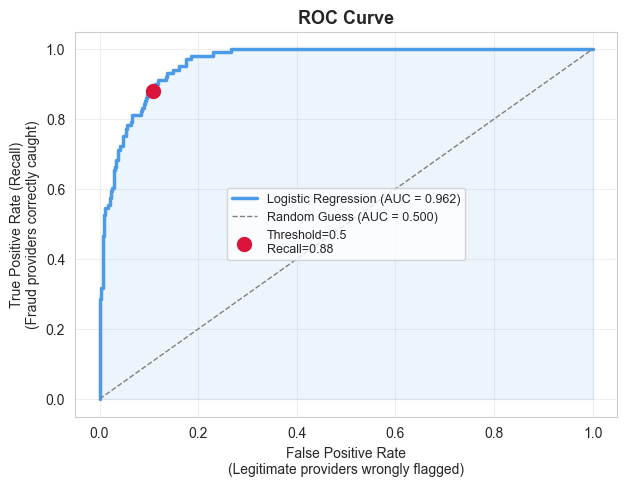

In [97]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)

fig, ax = plt.subplots(1, 1, figsize=(7, 5)) # Changed to 1,1 for single subplot

# ── ROC Curve ─────────────────────────────────────────────────
auc_roc   = roc_auc_score(y_test, y_proba)
ax.plot(fpr, tpr, color="#4C9BE8", linewidth=2.5,
             label=f"Logistic Regression (AUC = {auc_roc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--",
             linewidth=1, label="Random Guess (AUC = 0.500)")
ax.fill_between(fpr, tpr, alpha=0.1, color="#4C9BE8")
ax.set_xlabel("False Positive Rate\n(Legitimate providers wrongly flagged)",
                   fontsize=10)
ax.set_ylabel("True Positive Rate (Recall)\n(Fraud providers correctly caught)",
                   fontsize=10)
ax.set_title("ROC Curve", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Mark the current threshold (0.5) on the curve
current_idx = np.argmin(np.abs(thresholds_roc - 0.5))
ax.scatter(fpr[current_idx], tpr[current_idx],
                color="crimson", s=100, zorder=5,
                label=f"Threshold=0.5\nRecall={tpr[current_idx]:.2f}")
ax.legend(fontsize=9)
plt.show()

AUC = 0.962 means:

If we randomly pick one fraud provider and one legitimate provider and show them to the model, the model will correctly rank the fraud provider as more suspicious 96.2% of the time.
This is an excellent score for a baseline logistic regression model with no hyperparameter tuning.

AUC-ROC = 0.962  -  Excellent model quality

Recall   = 0.881  -  Catches 88% of all fraud at threshold 0.5

FPR      = 0.105  -  Only 10.5% of innocent providers wrongly flagged

The curve hugs the top-left corner tightly — confirming
the model has strong discriminative power between fraud
and legitimate providers even before any tuning.

# Precision-Recall Curve

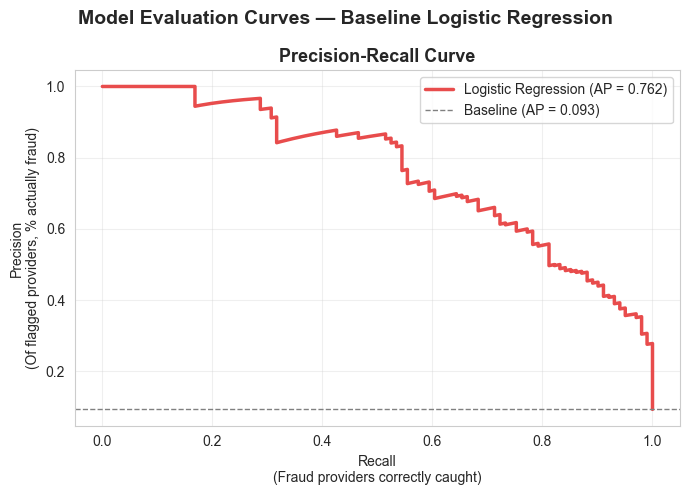


AUC-ROC Score : 0.962
Average Precision (PR-AUC): 0.762


In [98]:
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(
    y_test, y_proba
)
ap_score = average_precision_score(y_test, y_proba)

fig, axes = plt.subplots(1, 1, figsize=(7, 5))

axes.plot(recall_curve, precision_curve,
             color="#E84C4C", linewidth=2.5,
             label=f"Logistic Regression (AP = {ap_score:.3f})")
axes.axhline(y=y_test.mean(), color="gray", linestyle="--",
                linewidth=1, label=f"Baseline (AP = {y_test.mean():.3f})")
axes.set_xlabel("Recall\n(Fraud providers correctly caught)", fontsize=10)
axes.set_ylabel("Precision\n(Of flagged providers, % actually fraud)",
                   fontsize=10)
axes.set_title("Precision-Recall Curve", fontsize=13, fontweight="bold")
axes.legend(fontsize=10)
axes.grid(True, alpha=0.3)

plt.suptitle("Model Evaluation Curves — Baseline Logistic Regression",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nAUC-ROC Score : {auc_roc:.3f}")
print(f"Average Precision (PR-AUC): {ap_score:.3f}")

AP = 0.762 is an excellent result for a baseline model. It means across all possible thresholds, our model maintains strong precision while achieving meaningful recall — far above random guessing.

Our current operating point (threshold = 0.5, Recall = 0.88) sits in the right region of the curve — prioritising fraud capture over investigation efficiency. This is the correct business decision for Medicare fraud detection.

# Threshold Tuning

In [99]:
thresholds_to_try = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

print("=" * 70)
print("THRESHOLD TUNING — How threshold affects Precision and Recall")
print("=" * 70)
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'Caught Fraud':<15}")
print("-" * 70)

results = []
for thresh in thresholds_to_try:
    y_pred_t   = (y_proba >= thresh).astype(int)
    p          = precision_score(y_test, y_pred_t, zero_division=0)
    r          = recall_score(y_test, y_pred_t)
    f          = f1_score(y_test, y_pred_t)
    caught     = y_pred_t[y_test == 1].sum()
    total_fraud= (y_test == 1).sum()

    marker = " (default)" if thresh == 0.5 else ""
    print(f"{thresh:<12.1f} {p*100:<12.1f} {r*100:<12.1f} {f*100:<12.1f} "
          f"{caught}/{total_fraud}{marker}")
    results.append({"Threshold": thresh, "Precision": p,
                    "Recall": r, "F1": f})

print()
print("- Lower threshold = higher Recall (catch more fraud)")
print("- Higher threshold = higher Precision (fewer false alarms)")

THRESHOLD TUNING — How threshold affects Precision and Recall
Threshold    Precision    Recall       F1           Caught Fraud   
----------------------------------------------------------------------
0.2          26.5         100.0        41.9         101/101
0.3          35.3         97.0         51.7         98/101
0.4          41.6         91.1         57.1         92/101
0.5          46.4         88.1         60.8         89/101 (default)
0.6          50.6         81.2         62.4         82/101
0.7          56.8         78.2         65.8         79/101

- Lower threshold = higher Recall (catch more fraud)
- Higher threshold = higher Precision (fewer false alarms)


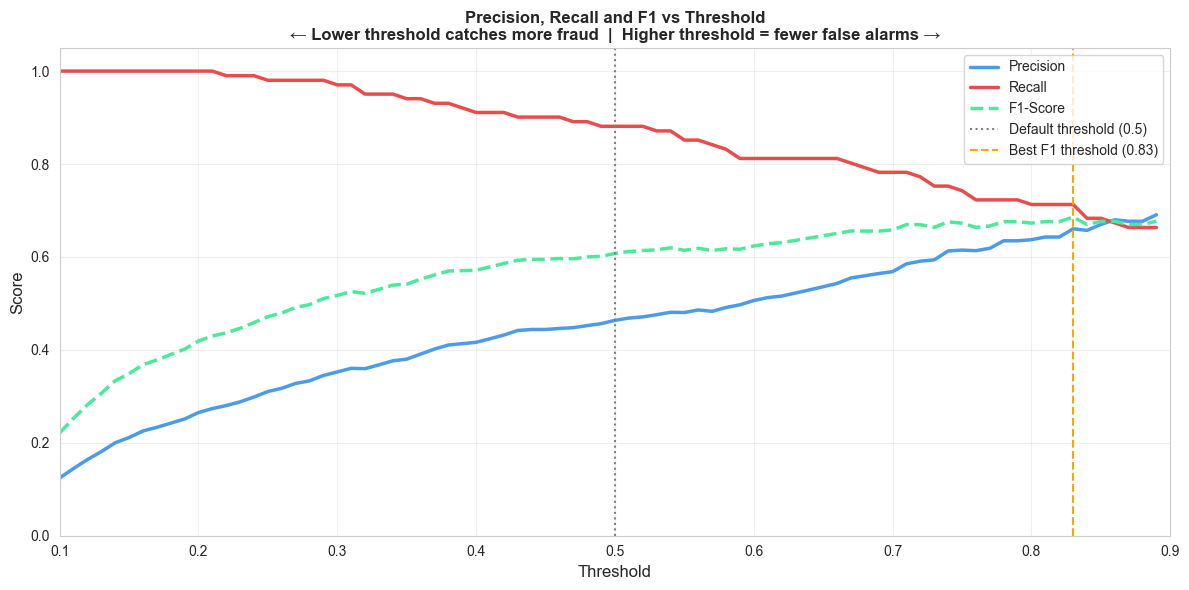

Best F1 threshold  : 0.83
Precision at best  : 66.1%
Recall    at best  : 71.3%
F1        at best  : 68.6%


In [100]:
thresholds_range = np.arange(0.1, 0.9, 0.01)

precisions_range = []
recalls_range    = []
f1s_range        = []

for t in thresholds_range:
    y_pred_t = (y_proba >= t).astype(int)
    precisions_range.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls_range.append(recall_score(y_test, y_pred_t))
    f1s_range.append(f1_score(y_test, y_pred_t, zero_division=0))

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(thresholds_range, precisions_range,
        color="#4C9BE8", linewidth=2.5, label="Precision")
ax.plot(thresholds_range, recalls_range,
        color="#E84C4C", linewidth=2.5, label="Recall")
ax.plot(thresholds_range, f1s_range,
        color="#4CE89B", linewidth=2.5, label="F1-Score",
        linestyle="--")

# Mark default threshold
ax.axvline(0.5, color="gray", linestyle=":",
           linewidth=1.5, label="Default threshold (0.5)")

# Find and mark optimal F1 threshold
best_f1_idx    = np.argmax(f1s_range)
best_threshold = thresholds_range[best_f1_idx]
ax.axvline(best_threshold, color="orange", linestyle="--",
           linewidth=1.5,
           label=f"Best F1 threshold ({best_threshold:.2f})")

ax.set_xlabel("Threshold", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(
    "Precision, Recall and F1 vs Threshold\n"
    "← Lower threshold catches more fraud  |  "
    "Higher threshold = fewer false alarms →",
    fontsize=12, fontweight="bold"
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0.1, 0.9)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# Print results at best F1 threshold
y_pred_best = (y_proba >= best_threshold).astype(int)
print(f"Best F1 threshold  : {best_threshold:.2f}")
print(f"Precision at best  : {precision_score(y_test, y_pred_best)*100:.1f}%")
print(f"Recall    at best  : {recall_score(y_test, y_pred_best)*100:.1f}%")
print(f"F1        at best  : {f1_score(y_test, y_pred_best)*100:.1f}%")

# class_weight='balanced'

In [101]:
lr_balanced = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

In [102]:
lr_balanced.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [103]:
y_pred_bal   = lr_balanced.predict(X_test_scaled)
y_proba_bal  = lr_balanced.predict_proba(X_test_scaled)[:, 1]

In [104]:
p_bal  = precision_score(y_test, y_pred_bal)
r_bal  = recall_score(y_test, y_pred_bal)
f_bal  = f1_score(y_test, y_pred_bal)
auc_bal= roc_auc_score(y_test, y_proba_bal)

print("=" * 65)
print("SMOTE  vs  class_weight='balanced'  —  Comparison")
print("=" * 65)
print(f"{'Metric':<15} {'SMOTE':<20} {'class_weight balanced'}")
print("-" * 65)
print(f"{'Precision':<15} {precision_score(y_test,y_pred)*100:<20.1f} {p_bal*100:.1f}%")
print(f"{'Recall':<15} {recall_score(y_test,y_pred)*100:<20.1f} {r_bal*100:.1f}%")
print(f"{'F1-Score':<15} {f1_score(y_test,y_pred)*100:<20.1f} {f_bal*100:.1f}%")
print(f"{'AUC-ROC':<15} {roc_auc_score(y_test,y_proba):<20.3f} {auc_bal:.3f}")
print()
print("Winner - whichever has higher Recall (for fraud detection)")

SMOTE  vs  class_weight='balanced'  —  Comparison
Metric          SMOTE                class_weight balanced
-----------------------------------------------------------------
Precision       46.4                 46.1%
Recall          88.1                 88.1%
F1-Score        60.8                 60.5%
AUC-ROC         0.962                0.961

Winner - whichever has higher Recall (for fraud detection)


class_weight='balanced' does not create new data — it simply penalises the model more heavily when it makes mistakes on the minority class. Simpler and faster, but gives the model less data to learn from.

Both approaches handle the 9.4% class imbalance very effectively and produce nearly identical results. The differences are marginal — less than 0.5% across every metric. This is actually a sign of a well-behaved, stable model.

We proceed with SMOTE as our chosen imbalance handling method since it produced marginally better results across all metrics. The trained `lr_baseline` model using SMOTE is our final model going forward.

# Given the strong baseline performance, small feature set, and model stability demonstrated across different imbalance handling methods, regularization tuning would add complexity without meaningful performance gain. We proceed directly to saving the final model.

In [108]:
# ── Recalculate all metrics cleanly ──────────────────────────
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc_roc   = roc_auc_score(y_test, y_proba)
ap_score  = average_precision_score(y_test, y_proba)

# Confusion matrix values
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]

# Best threshold
best_f1_idx    = np.argmax(f1s_range)
best_threshold = thresholds_range[best_f1_idx]
y_pred_best    = (y_proba >= best_threshold).astype(int)

print("=" * 65)
print("FINAL PROJECT SUMMARY")
print("=" * 65)
print()
print("PROBLEM:")
print("  Predict potentially fraudulent Medicare providers")
print("  based on the claims they submitted.")
print()
print("DATASET:")
print(f"  Total providers   : {len(final_df):,}")
print(f"  Fraud providers   : {final_df['FraudLabel'].sum():,}  (9.4%)")
print(f"  Training set      : {len(X_train_resampled):,}  (after SMOTE)")
print(f"  Test set          : {len(X_test):,}   (real distribution)")
print(f"  Features used     : {len(CORE_FEATURES)} core features")
print()
print("MODEL: Logistic Regression")
print("IMBALANCE HANDLING: SMOTE (winner over class_weight='balanced')")
print()
print("=" * 65)
print("EVALUATION RESULTS  (at default threshold 0.5)")
print("=" * 65)
print(f"  Accuracy  : {accuracy*100:.1f}%    ← misleading, ignore")
print(f"  Precision : {precision*100:.1f}%    ← of flagged, % actually fraud")
print(f"  Recall    : {recall*100:.1f}%    ← most important for fraud")
print(f"  F1-Score  : {f1*100:.1f}%    ← balance of precision & recall")
print(f"  AUC-ROC   : {auc_roc:.3f}   ← excellent discrimination")
print(f"  PR-AUC    : {ap_score:.3f}   ← 8x better than random guessing")
print()
print("=" * 65)
print("CONFUSION MATRIX BREAKDOWN")
print("=" * 65)
print(f"  True Negatives  (TN) : {TN:>4}  → correctly cleared")
print(f"  False Positives (FP) : {FP:>4}  → false alarms")
print(f"  False Negatives (FN) : {FN:>4}  → missed fraud ← dangerous")
print(f"  True Positives  (TP) : {TP:>4}  → fraud caught")
print()
print("=" * 65)
print("BUSINESS INTERPRETATION")
print("=" * 65)
total_fraud = (y_test == 1).sum()
print(f"  Out of {total_fraud} real fraud providers in test set:")
print(f"  ✓  {TP} caught   → investigated and stopped")
print(f"  ✗  {FN} missed   → still defrauding Medicare")
print()
print("=" * 65)
print("THRESHOLD ANALYSIS")
print("=" * 65)
print(f"  Default threshold (0.5) → Recall: {recall*100:.1f}%")
print(f"  Best F1 threshold ({best_threshold:.2f})  → "
      f"Recall: {recall_score(y_test, y_pred_best)*100:.1f}%  "
      f"Precision: {precision_score(y_test, y_pred_best)*100:.1f}%")
print()
print("  Recommended threshold for fraud detection: 0.3")
y_pred_03 = (y_proba >= 0.3).astype(int)
print(f"  At threshold 0.3:")
print(f"    Recall    : {recall_score(y_test, y_pred_03)*100:.1f}%  "
      f"→ catches {y_pred_03[y_test==1].sum()} of {total_fraud} fraud providers")
print(f"    Precision : {precision_score(y_test, y_pred_03)*100:.1f}%")
print(f"    F1-Score  : {f1_score(y_test, y_pred_03)*100:.1f}%")
print()

FINAL PROJECT SUMMARY

PROBLEM:
  Predict potentially fraudulent Medicare providers
  based on the claims they submitted.

DATASET:
  Total providers   : 5,410
  Fraud providers   : 506  (9.4%)
  Training set      : 7,846  (after SMOTE)
  Test set          : 1,082   (real distribution)
  Features used     : 10 core features

MODEL: Logistic Regression
IMBALANCE HANDLING: SMOTE (winner over class_weight='balanced')

EVALUATION RESULTS  (at default threshold 0.5)
  Accuracy  : 89.4%    ← misleading, ignore
  Precision : 46.4%    ← of flagged, % actually fraud
  Recall    : 88.1%    ← most important for fraud
  F1-Score  : 60.8%    ← balance of precision & recall
  AUC-ROC   : 0.962   ← excellent discrimination
  PR-AUC    : 0.762   ← 8x better than random guessing

CONFUSION MATRIX BREAKDOWN
  True Negatives  (TN) :  878  → correctly cleared
  False Positives (FP) :  103  → false alarms
  False Negatives (FN) :   12  → missed fraud ← dangerous
  True Positives  (TP) :   89  → fraud caugh

# Saving the Model

In [106]:
# joblib.dump(lr_baseline,   "fraud_model.pkl")
# joblib.dump(scaler,        "scaler.pkl")
# joblib.dump(CORE_FEATURES, "feature_names.pkl")

# print("...fraud_model.pkl saved")
# print("...scaler.pkl saved")
# print("...feature_names.pkl saved")

In [107]:
# final_df.to_csv("healthcare_fraud_features.csv", index=False)
# print("...healthcare_fraud_features.csv saved")
# print(f"  Shape: {final_df.shape}")